# Avance 4 — Modelos alternativos (Equipo 17, AgroSatCopilot)

## Proyecto Integrador MNA · Tec de Monterrey

**Equipo 17**

- Carlos Isaac Ávila Gutiérrez — A01796035
- Carlos Aaron Bocanegra Buitrón — A01796345
- Arthur Jafed Zizumbo Velasco — A01796363

**Curso**: Proyecto Integrador

**Sponsor académico**: Dr. Gerardo José Camacho — gjcamacho@tec.mx

**Fecha de entrega**: 2026-05-31.

---

## Resumen ejecutivo

Este cuaderno **consolida** las **6 arquitecturas individuales** (no ensambles) de segmentación semántica densa de cultivos sobre PASTIS-R, repartidas entre el equipo. Consume los parquets comparativos que cada integrante exporta, construye la tabla de los 6 modelos ordenada por la métrica principal (mIoU), selecciona el top-2, documenta el ajuste fino (Optuna) y la elección del modelo individual final.

| # | Modelo | Tipo |
|---|--------|------|
| 1 | U-Net ResNet-50 | CNN clásica 2D |
| 2 | DeepLabv3+ MobileNet | CNN eficiente ASPP |
| 3 | SegFormer-B0 | Transformer spatial |
| 4 | U-TAE | Temporal Attention |
| 5 | TSViT | Transformer temporal (Paper 1) |
| 6 | AnySat frozen + linear head | Foundation model congelado |


## Objetivos y rubrica

- **3.3** Explorar una gama diversa de tecnicas (6 arquitecturas).
- **3.4** Encontrar la configuracion optima (ajuste fino del top-2).

**Distribucion de puntos**:

- **Comparativa (60 pts)**: >=6 modelos, tabla ordenada por mIoU + F1-macro + pixel-accuracy + tiempos de entrenamiento.
- **Ajuste fino (30 pts)**: Optuna (>=30 trials) sobre los 2 mejores.
- **Modelo individual (10 pts)**: justificacion del final (trade-offs, no solo metrica).

In [1]:
# --- Setup Colab + Drive compartido del equipo ---
import os, subprocess, sys
from pathlib import Path

# Monta Drive y prefija las rutas con shared_folder_path (vacio en local).
_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

# Este cuaderno es integrador: solo consolida parquets/figuras desde Drive y NO
# importa codigo del repo. Si el repo esta presente se usa como cwd, pero no es
# obligatorio (a diferencia de los notebooks de modelo, que si clonan el repo).
_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break

# Dependencias de visualizacion (polars no viene por defecto en Colab).
if _IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install', 'polars'], check=False)

import matplotlib.pyplot as plt
# render PNG inline (barplot + galeria) en papermill:
%matplotlib inline
import polars as pl
print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

repo: C:\Users\arthu\Proyectos\MNA\agro_sat_copilot | colab: False | drive: (local)


## Metodologia

- **Dataset**: PASTIS-R (2433 patches Sentinel-2 multitemporales, 20 clases, folds oficiales espacialmente disjuntos -> sin leakage).
- **Convencion compartida**: `num_classes=20`, `ignore_index=19` (void), resolucion **256px**, split train=folds[1,2,3] / val=fold[4] / test=fold[5].
- **Metricas**: mIoU (principal) + F1-macro + pixel-accuracy, todas pixel-level (`ml/eval/dense_metrics.py`).
- **Tracking**: 1 run MLflow por modelo con tag `architecture`.

## Comparativa de los 6 modelos (60 pts)

In [2]:
# --- Consolidar los parquets de los integrantes (desde el Drive compartido) ---
REPORTS = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/metrics')
FIGURES = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/figures')
# Los 6 modelos del Avance 4. El integrador muestra los que ya exportaron su
# parquet y deja placeholder para los pendientes (no hay que tocar el notebook).
EXPECTED = ['unet', 'anysat', 'deeplabv3plus', 'segformer', 'utae', 'tsvit']
parts = sorted(REPORTS.glob('model_comparison_avance4_*.parquet'))
_avail = {p.stem.replace('model_comparison_avance4_', '').replace('_fast', '')
          for p in parts}
print('disponibles:', sorted(_avail))
print('pendientes :', [m for m in EXPECTED if m not in _avail])

if parts:
    table = pl.concat([pl.read_parquet(p) for p in parts], how='vertical_relaxed')
    table = table.unique(subset=['model'], keep='last').sort('miou', descending=True)
else:
    print('Aun no hay parquets en', REPORTS)
    table = pl.DataFrame()

_cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
         'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in _cols if c in table.columns]) if table.height else table

disponibles: ['anysat', 'deeplabv3plus', 'segformer', 'tsvit', 'unet', 'utae']
pendientes : []


model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""tsvit-pheno""",null,null,null,0.6253,0.75,0.8759,null,30
"""tsvit""",null,null,null,0.6215,0.7473,0.8724,null,30
"""utae""",0.4998,null,null,0.4742,0.6087,null,null,null
"""anysat""",0.591262,0.720331,0.717393,0.445935,0.571575,0.750092,2.824724,30
"""deeplabv3plus""",0.4682,0.6009,0.8018,0.2709,0.3864,0.6743,null,15
"""unet""",0.452094,0.590586,0.723277,0.242317,0.346336,0.691786,1.177502,30
"""segformer""",0.2369,null,null,0.2325,0.3423,null,null,null


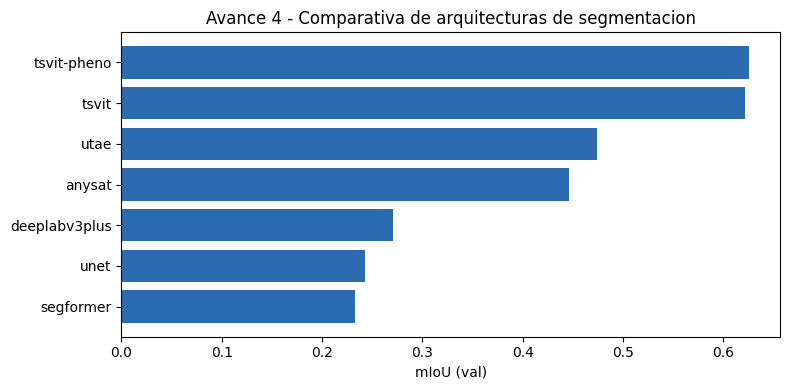

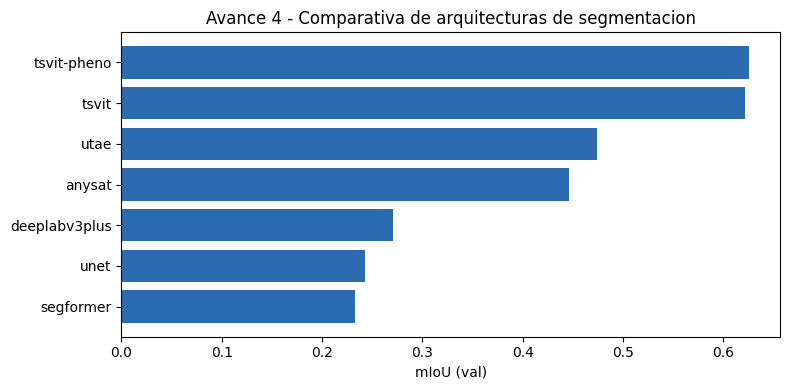

In [3]:
# --- Barplot comparativo (mIoU por modelo) ---
if table.height:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(table['model'].to_list()[::-1], table['miou'].to_list()[::-1], color='#2b6cb0')
    ax.set_xlabel('mIoU (val)')
    ax.set_title('Avance 4 - Comparativa de arquitecturas de segmentacion')
    fig.tight_layout()
    display(fig)
else:
    print('Tabla vacia: nada que graficar todavia.')

In [4]:
# --- Top-2 del equipo: solo se considera `tsvit-pheno` como variante TSViT
#     candidata (la mejor); `tsvit` base queda en la tabla como referencia del
#     aporte de la fenologia, pero no compite por el top-2. El resto del ranking
#     sale por mIoU de la tabla consolidada (data-driven, desde los parquets).
from IPython.display import Markdown, display

if table.height:
    _ranking = table.filter(pl.col("model") != "tsvit")
    _top2 = _ranking.head(2)["model"].to_list()
    _msg = ", ".join(f"`{m}`" for m in _top2)
    display(Markdown(
        f"**Top-2 al momento (por mIoU, contando solo `tsvit-pheno` como "
        f"variante TSViT):** {_msg}. `tsvit` base se reporta en la tabla como "
        f"referencia del aporte de la fenologia, no como candidato."
    ))
else:
    display(Markdown("_Tabla vacia: aun no hay parquets de modelos._"))

**Top-2 al momento (por mIoU, contando solo `tsvit-pheno` como variante TSViT):** `tsvit-pheno`, `utae`. `tsvit` base se reporta en la tabla como referencia del aporte de la fenologia, no como candidato.

Por ahora hay dos de los seis modelos, U-Net ResNet-50 (#1) y AnySat congelado + cabeza lineal (#6); faltan DeepLabv3+, SegFormer, U-TAE y TSViT de los otros integrantes, que el cuaderno suma solo cuando exporten su parquet. Entre los dos que estan, AnySat queda claramente adelante: sobre los 6 grupos HCAT da mIoU 0.59, F1-macro 0.72 y exactitud 0.72, contra 0.45, 0.59 y 0.72 de la U-Net. La diferencia se agranda en las 18 clases planas (mIoU 0.45 vs 0.24), donde la serie temporal de AnySat ayuda a separar cultivos que en una sola fecha se confunden; la U-Net solo empata en pixel-accuracy, que esta dominada por las clases frecuentes.

Un detalle de lectura: la columna train_time_s de la tabla corresponde al ultimo resume de cada modelo, no al entrenamiento completo. Los tiempos reales fueron del orden de ~59 min para AnySat (solo la cabeza) y ~95 min para la U-Net (red entera) en una GPU L4.

## Reportes visuales por modelo

Para cada modelo: curvas de entrenamiento, IoU por clase, matriz de confusión y la comparación RGB / verdad / predicción, tal como las dejó cada notebook en `reports/segmentation/figures/`. Los modelos que todavía no corrieron muestran un placeholder, así el cuaderno se completa solo a medida que cada uno entrena.

### unet

**Curvas de entrenamiento**

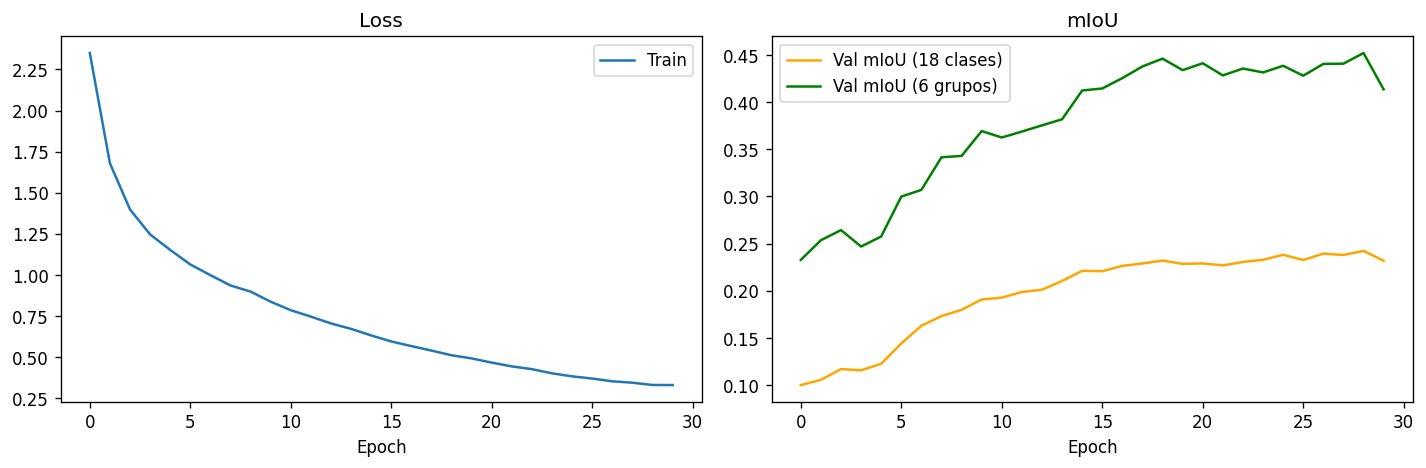

**IoU por clase**

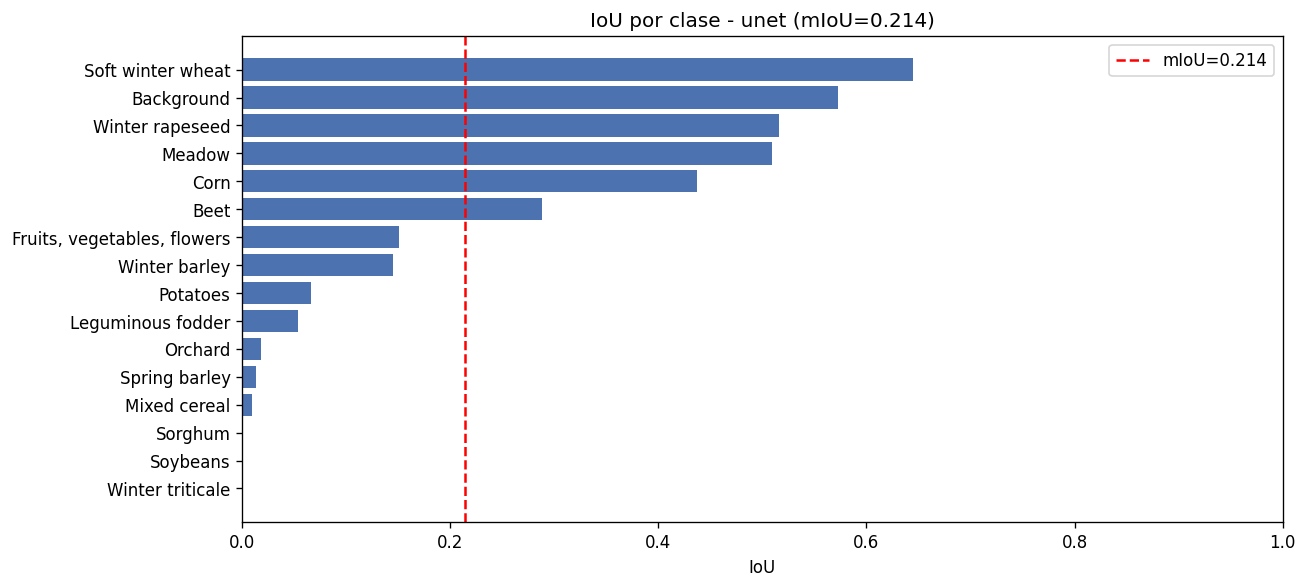

**Matriz de confusion**

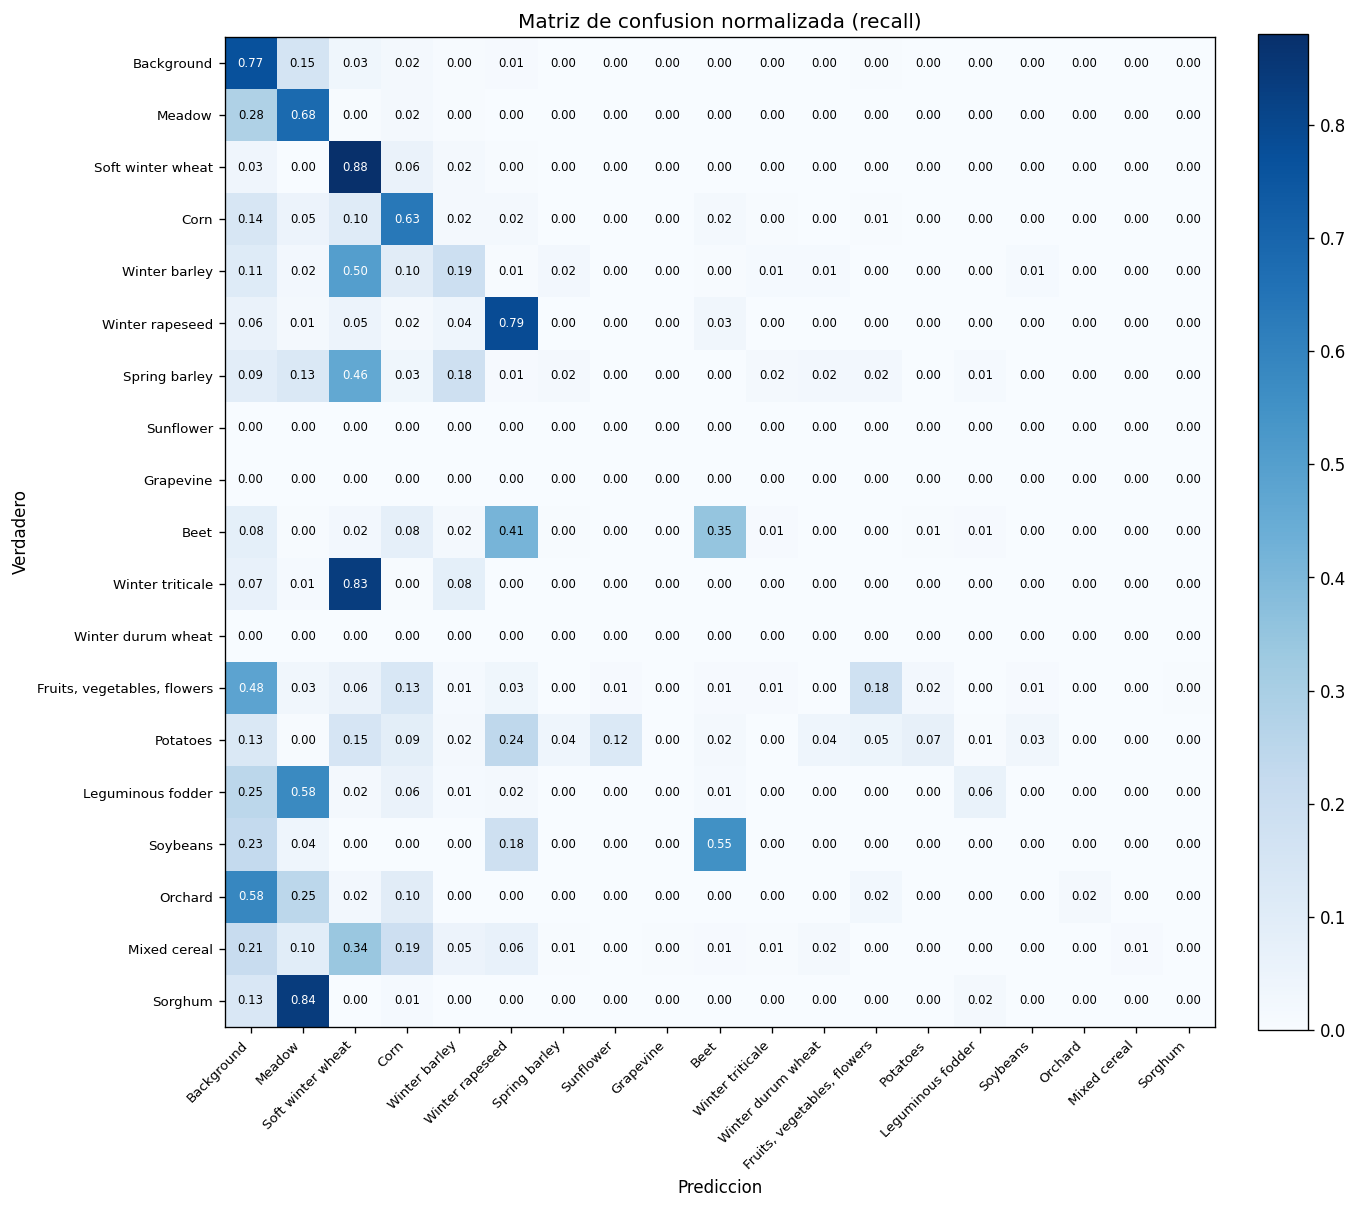

**RGB / verdad / prediccion**

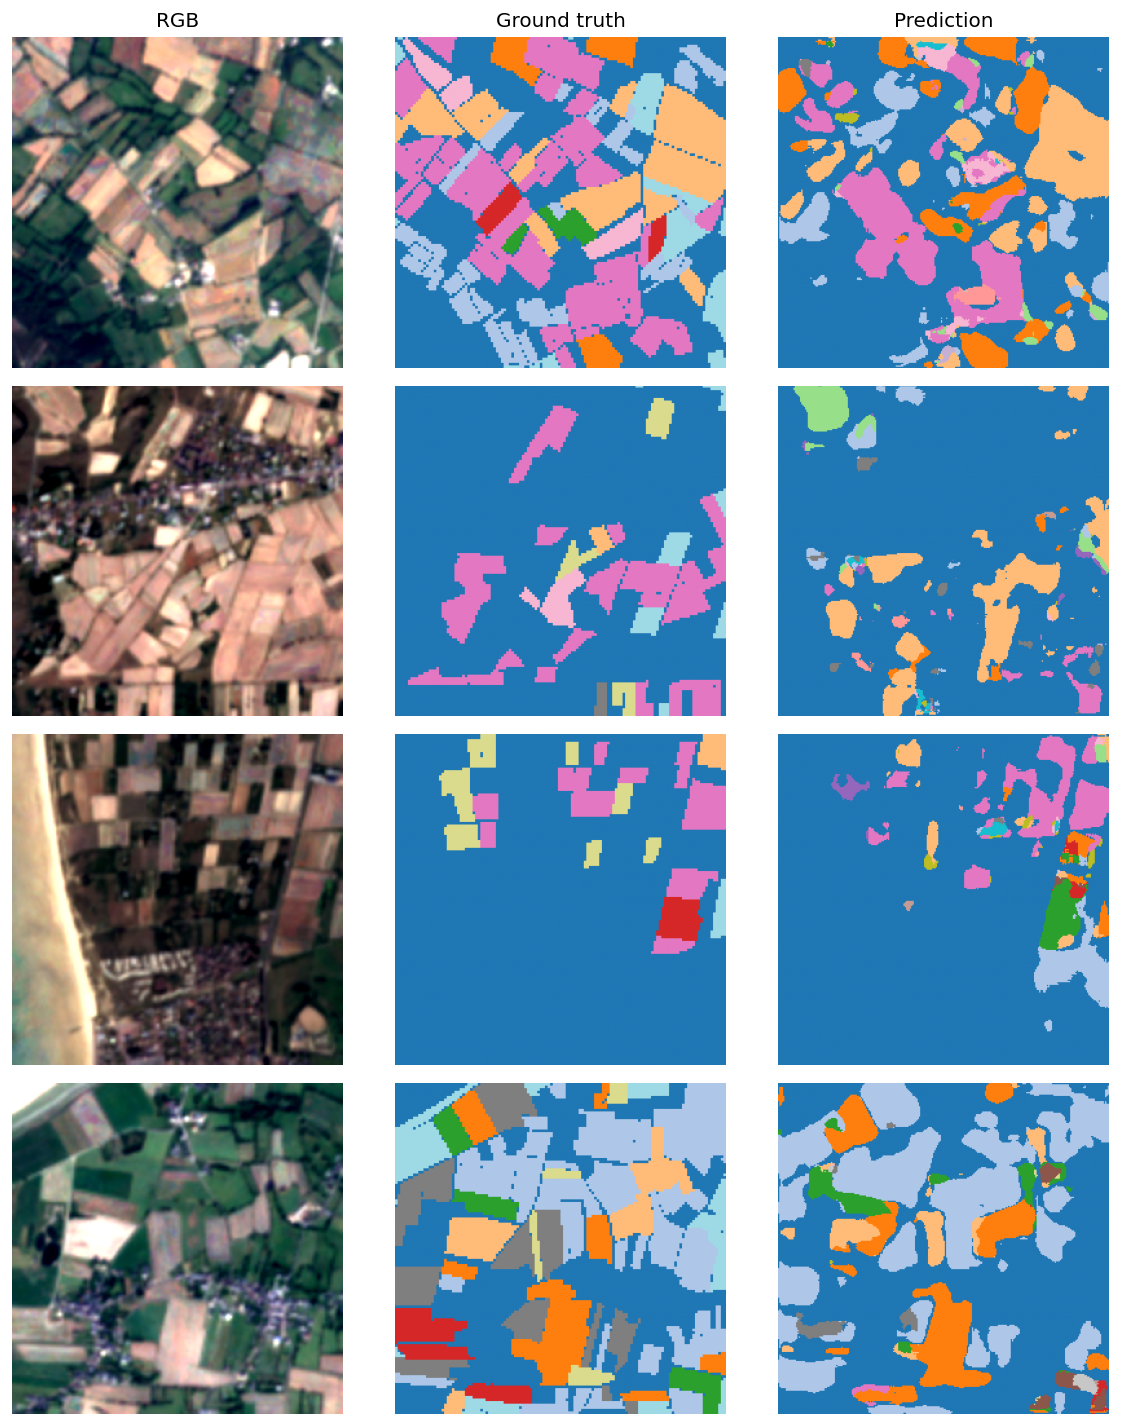

### anysat

**Curvas de entrenamiento**

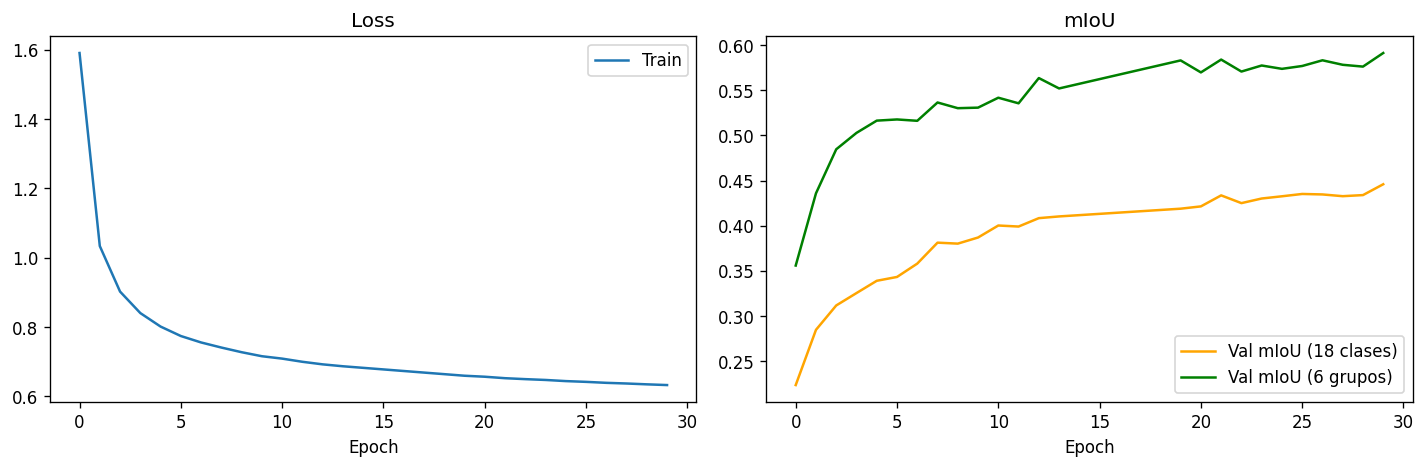

**IoU por clase**

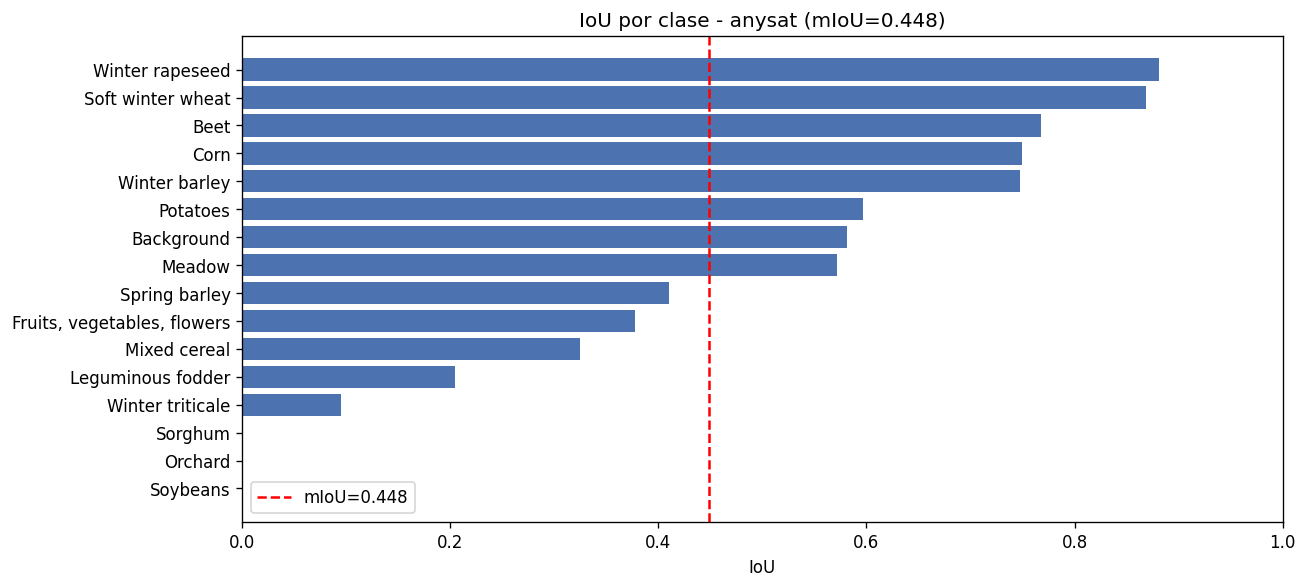

**Matriz de confusion**

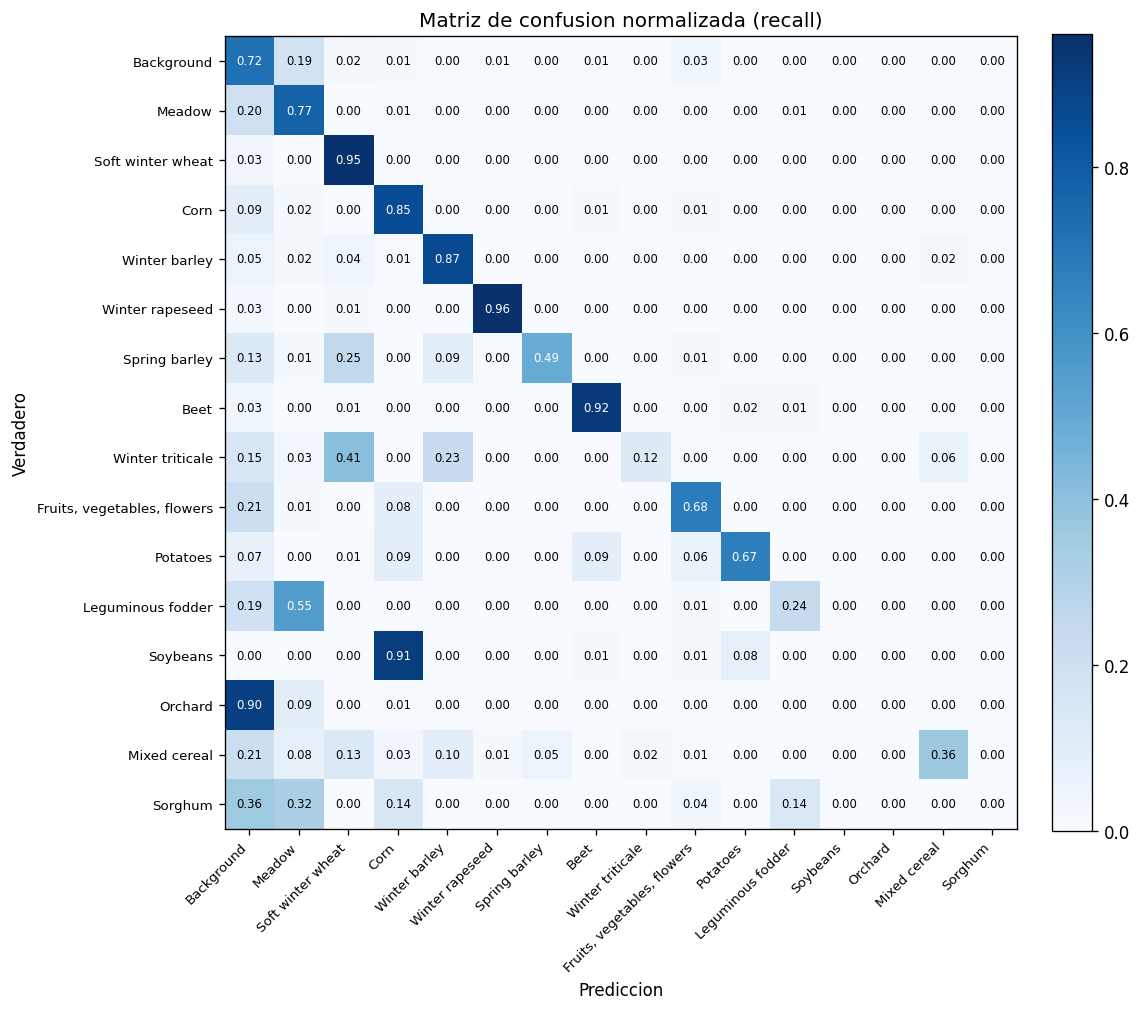

**RGB / verdad / prediccion**

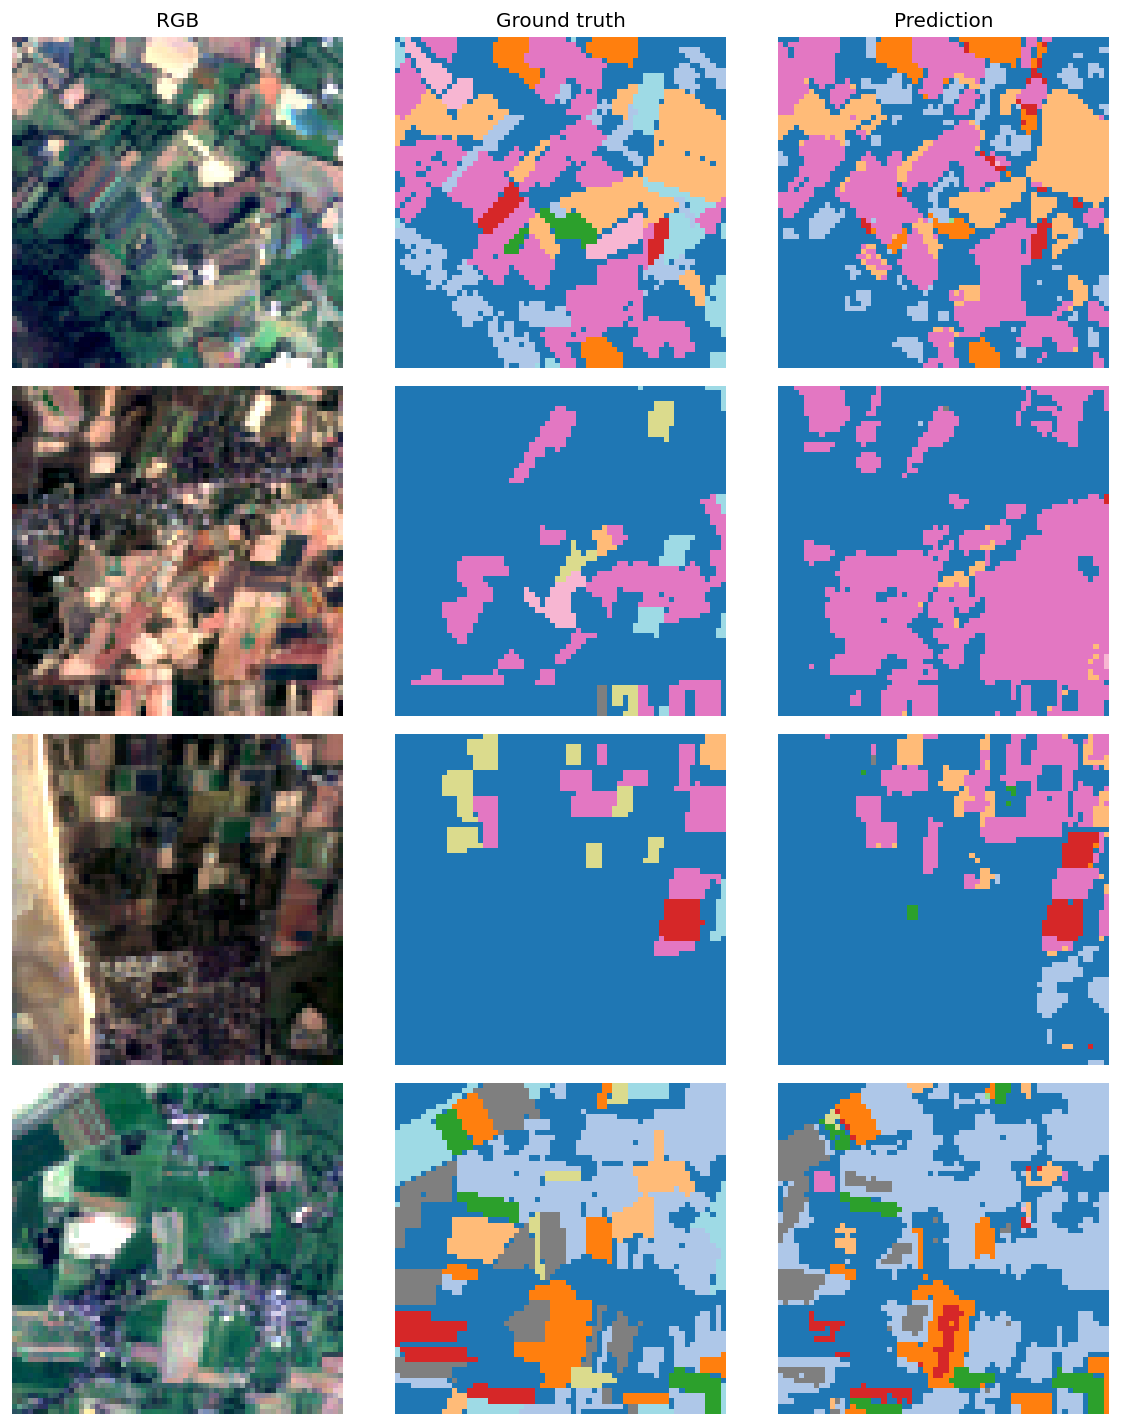

### deeplabv3plus

**Matriz de confusion**

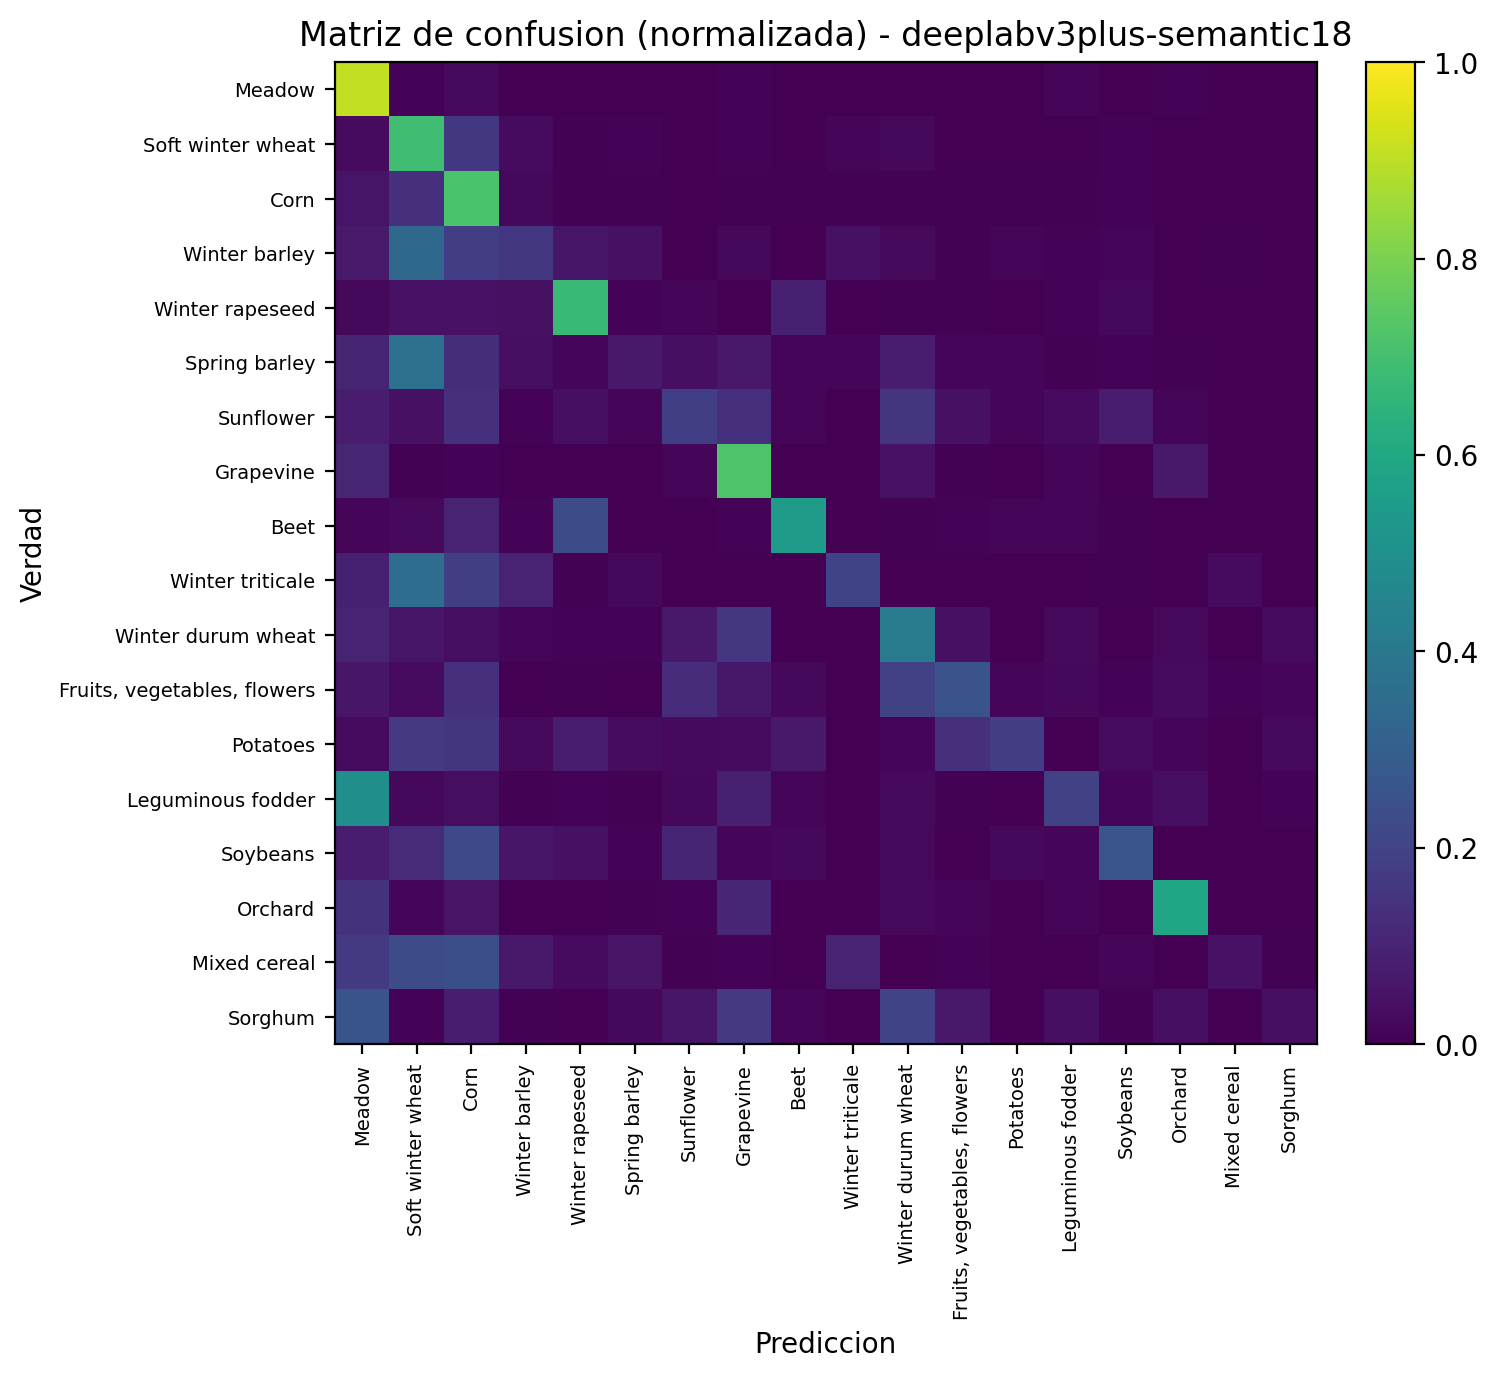

**RGB / verdad / prediccion**

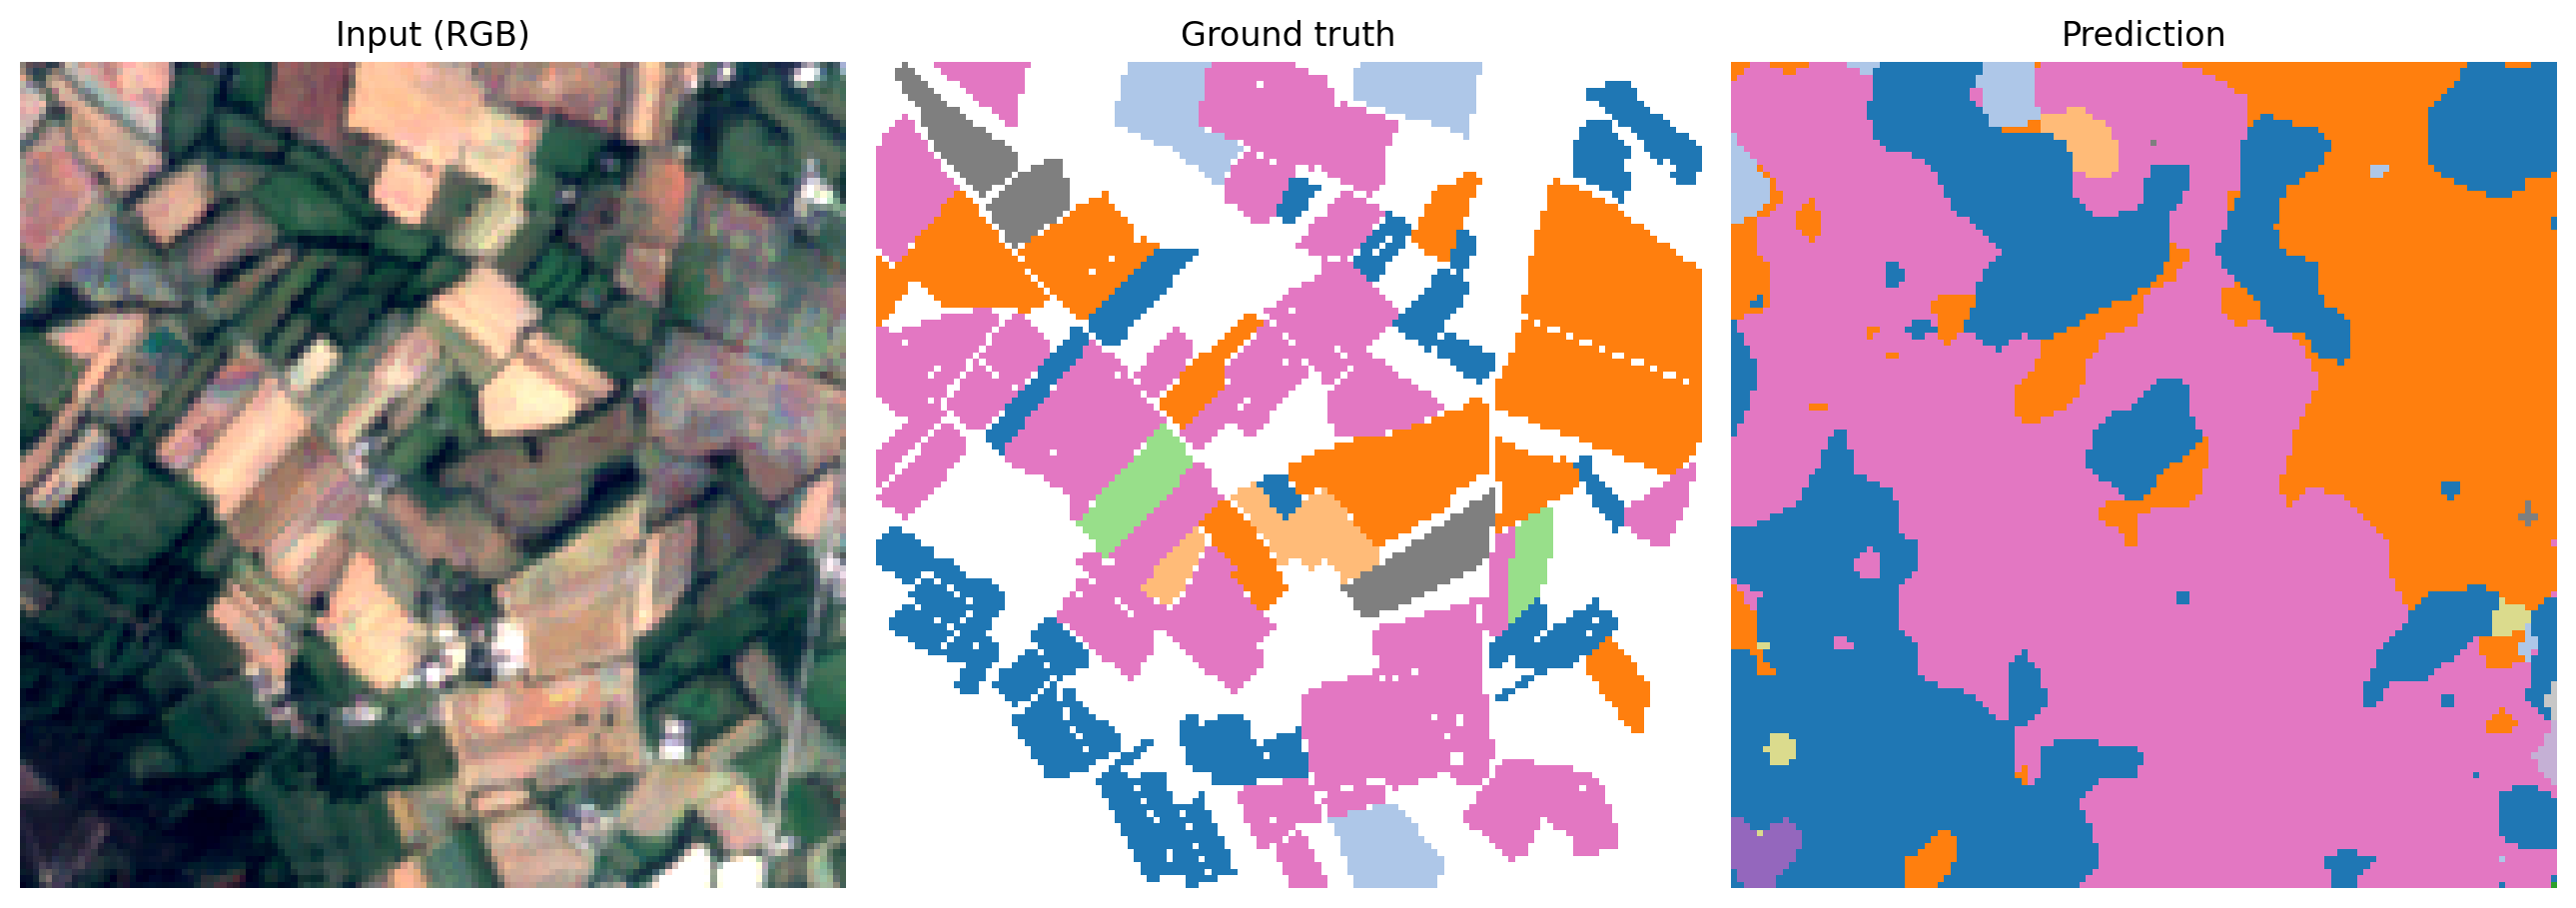

### segformer

**Curvas de entrenamiento**

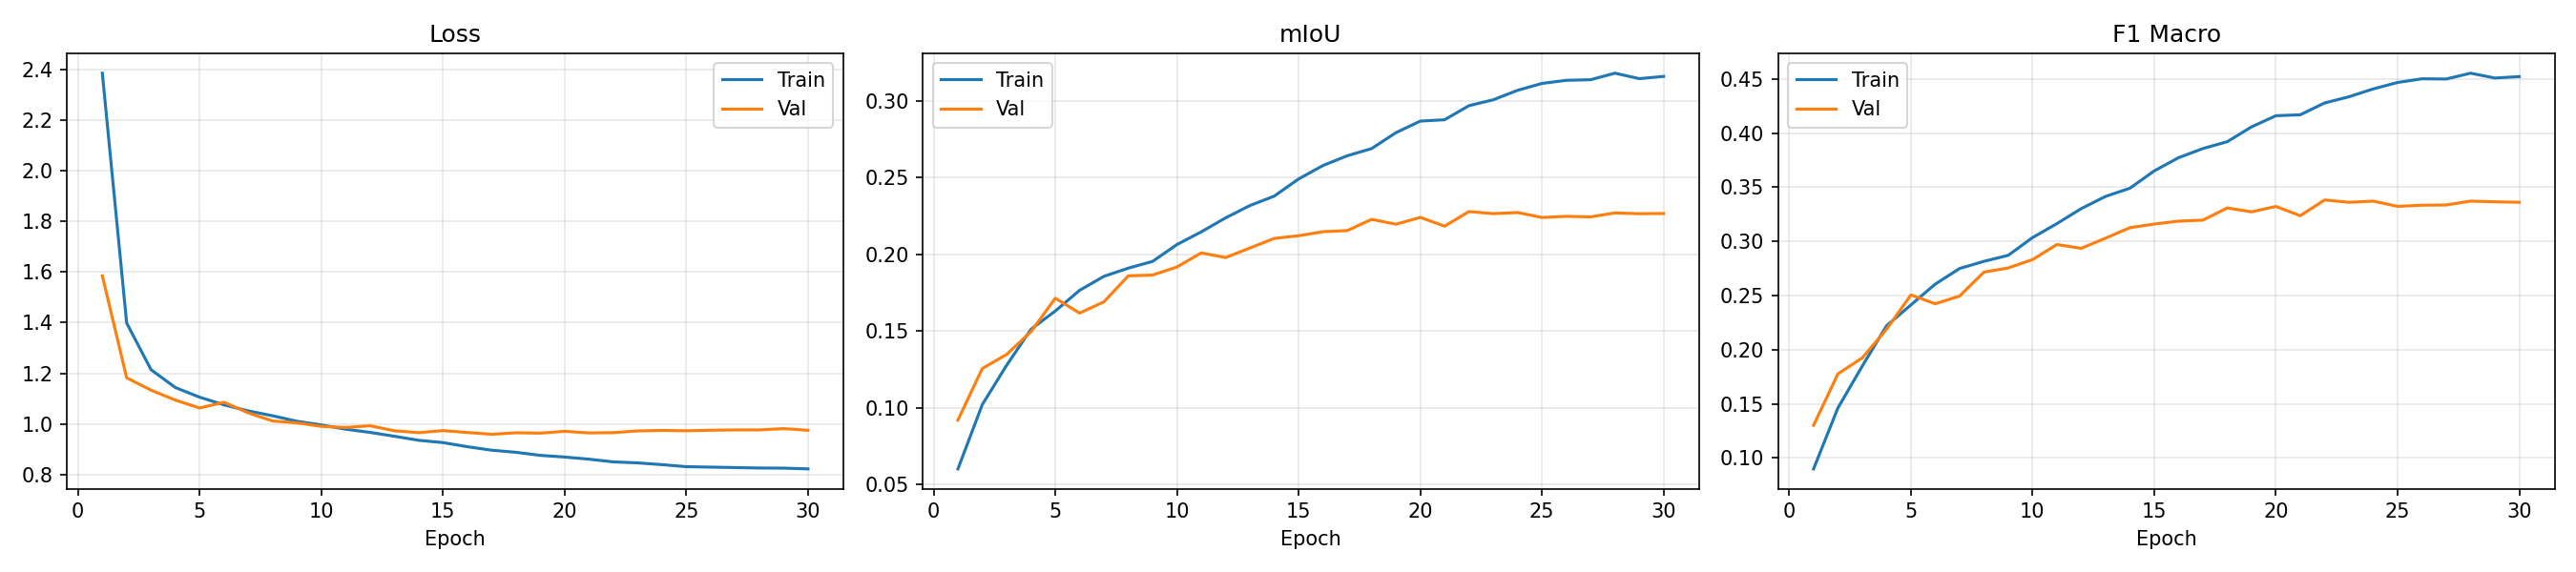

**IoU por clase**

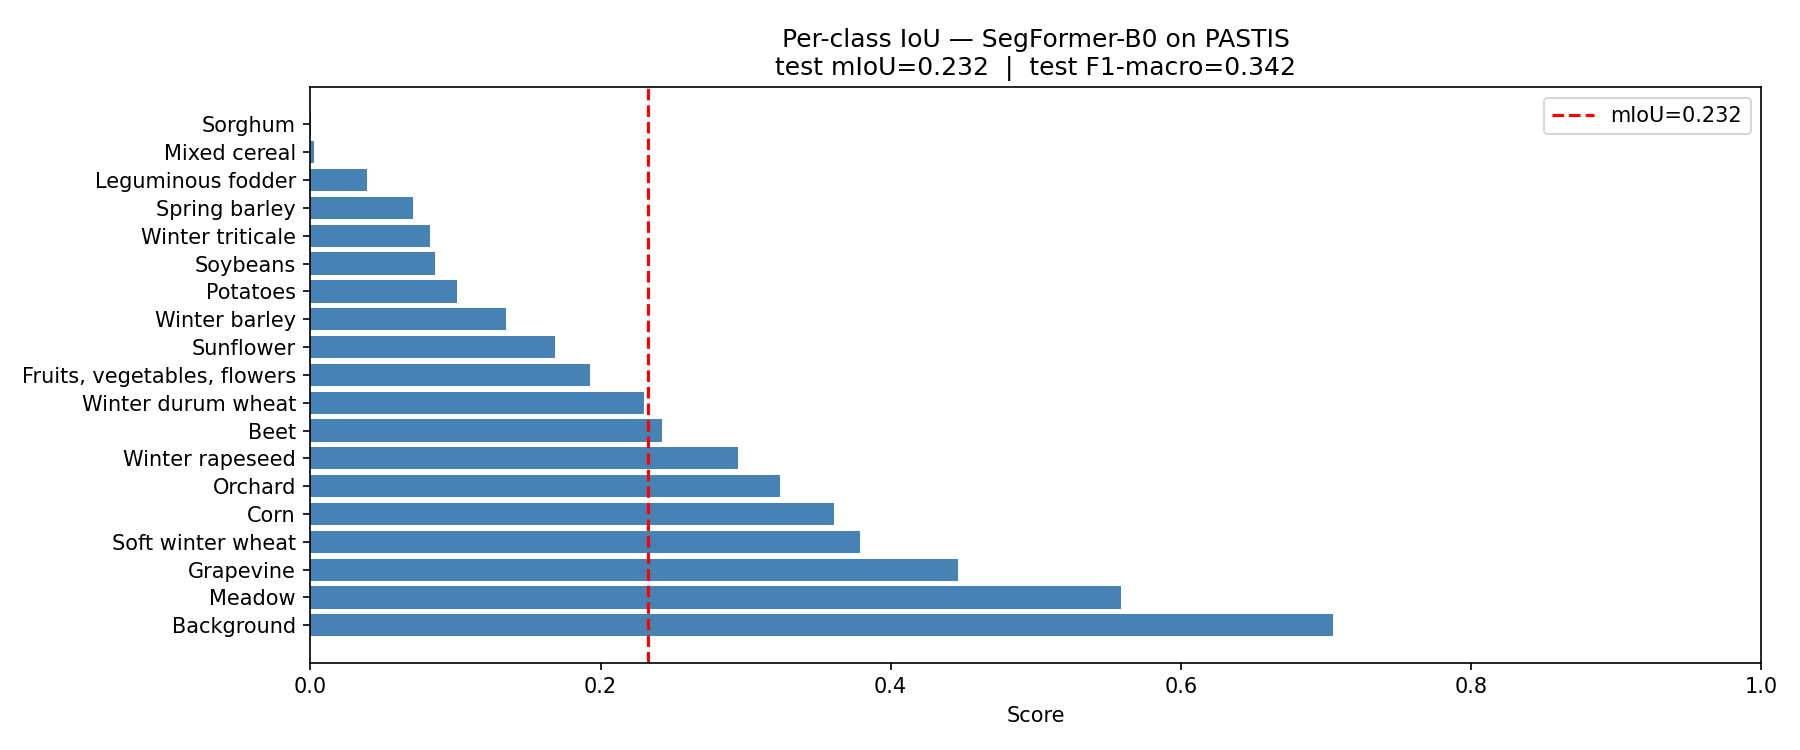

**RGB / verdad / prediccion**

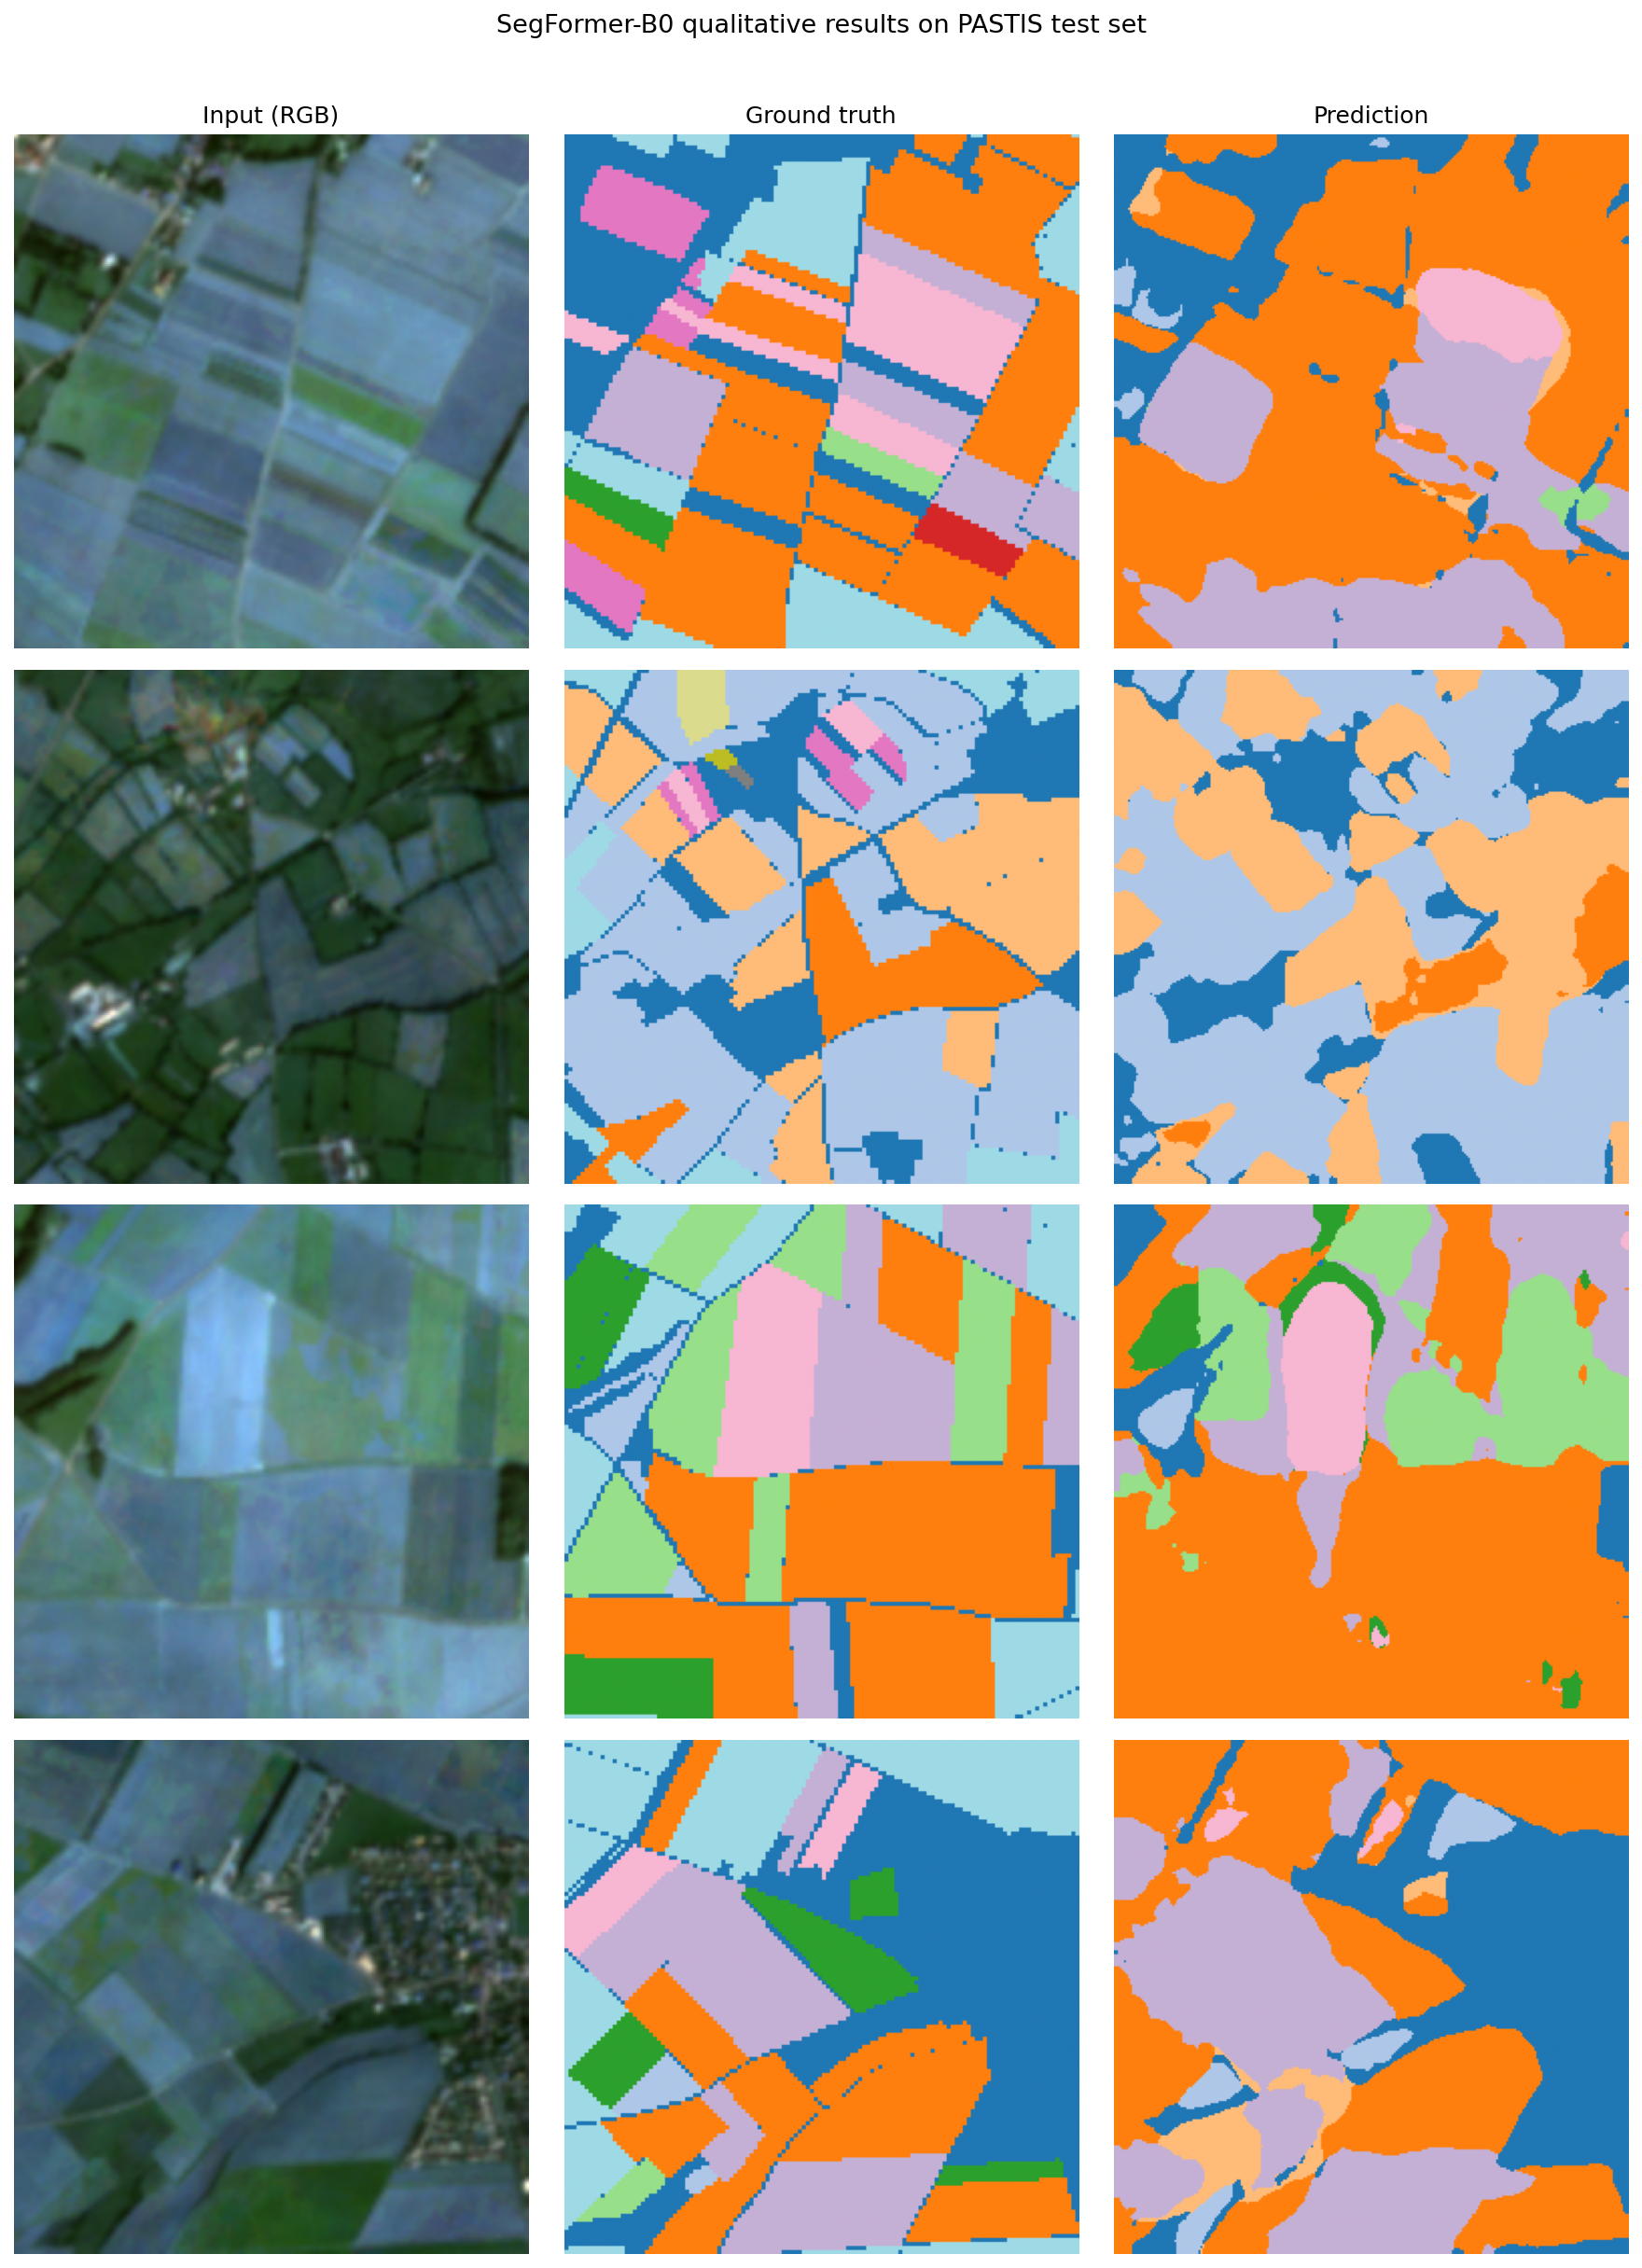

### utae

**Curvas de entrenamiento**

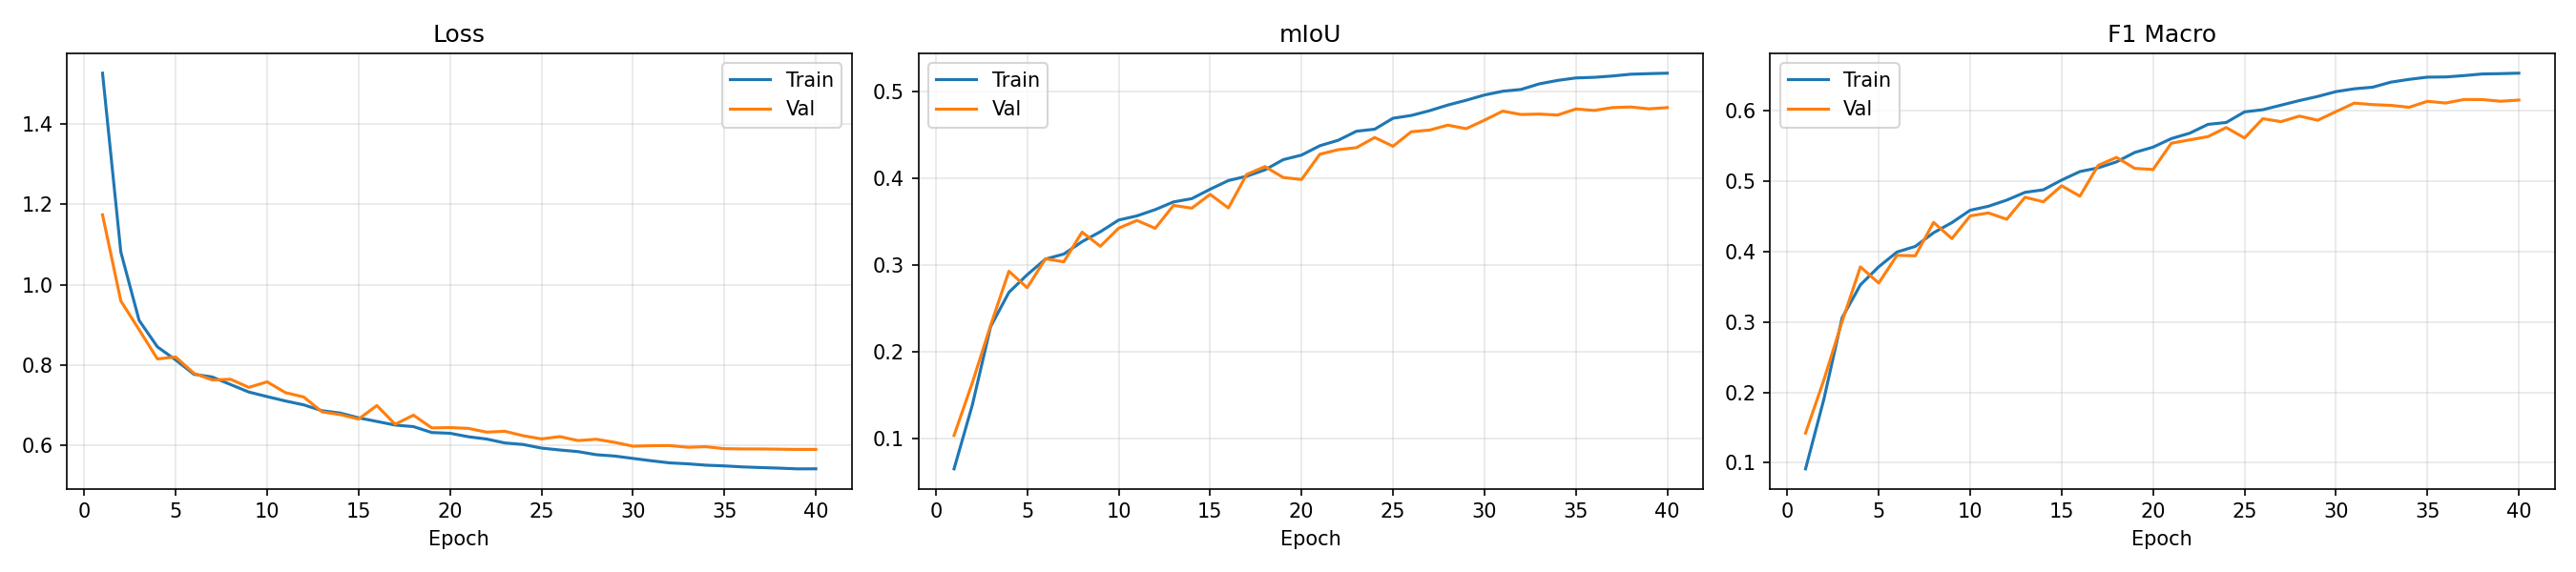

**IoU por clase**

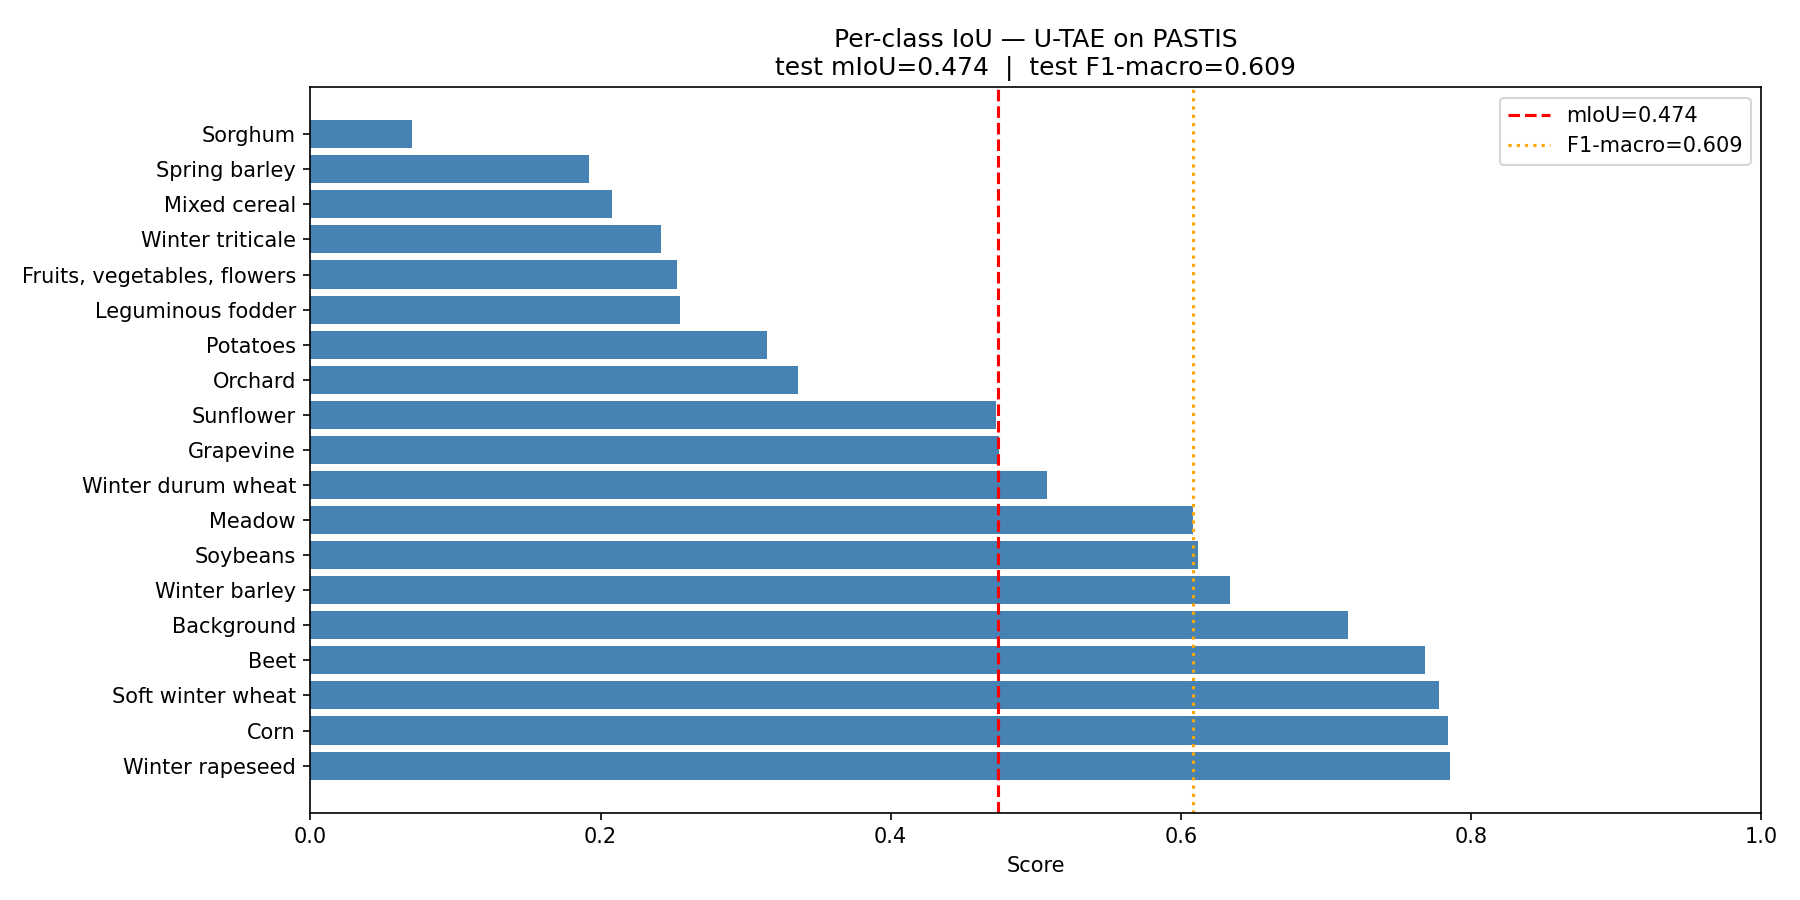

**RGB / verdad / prediccion**

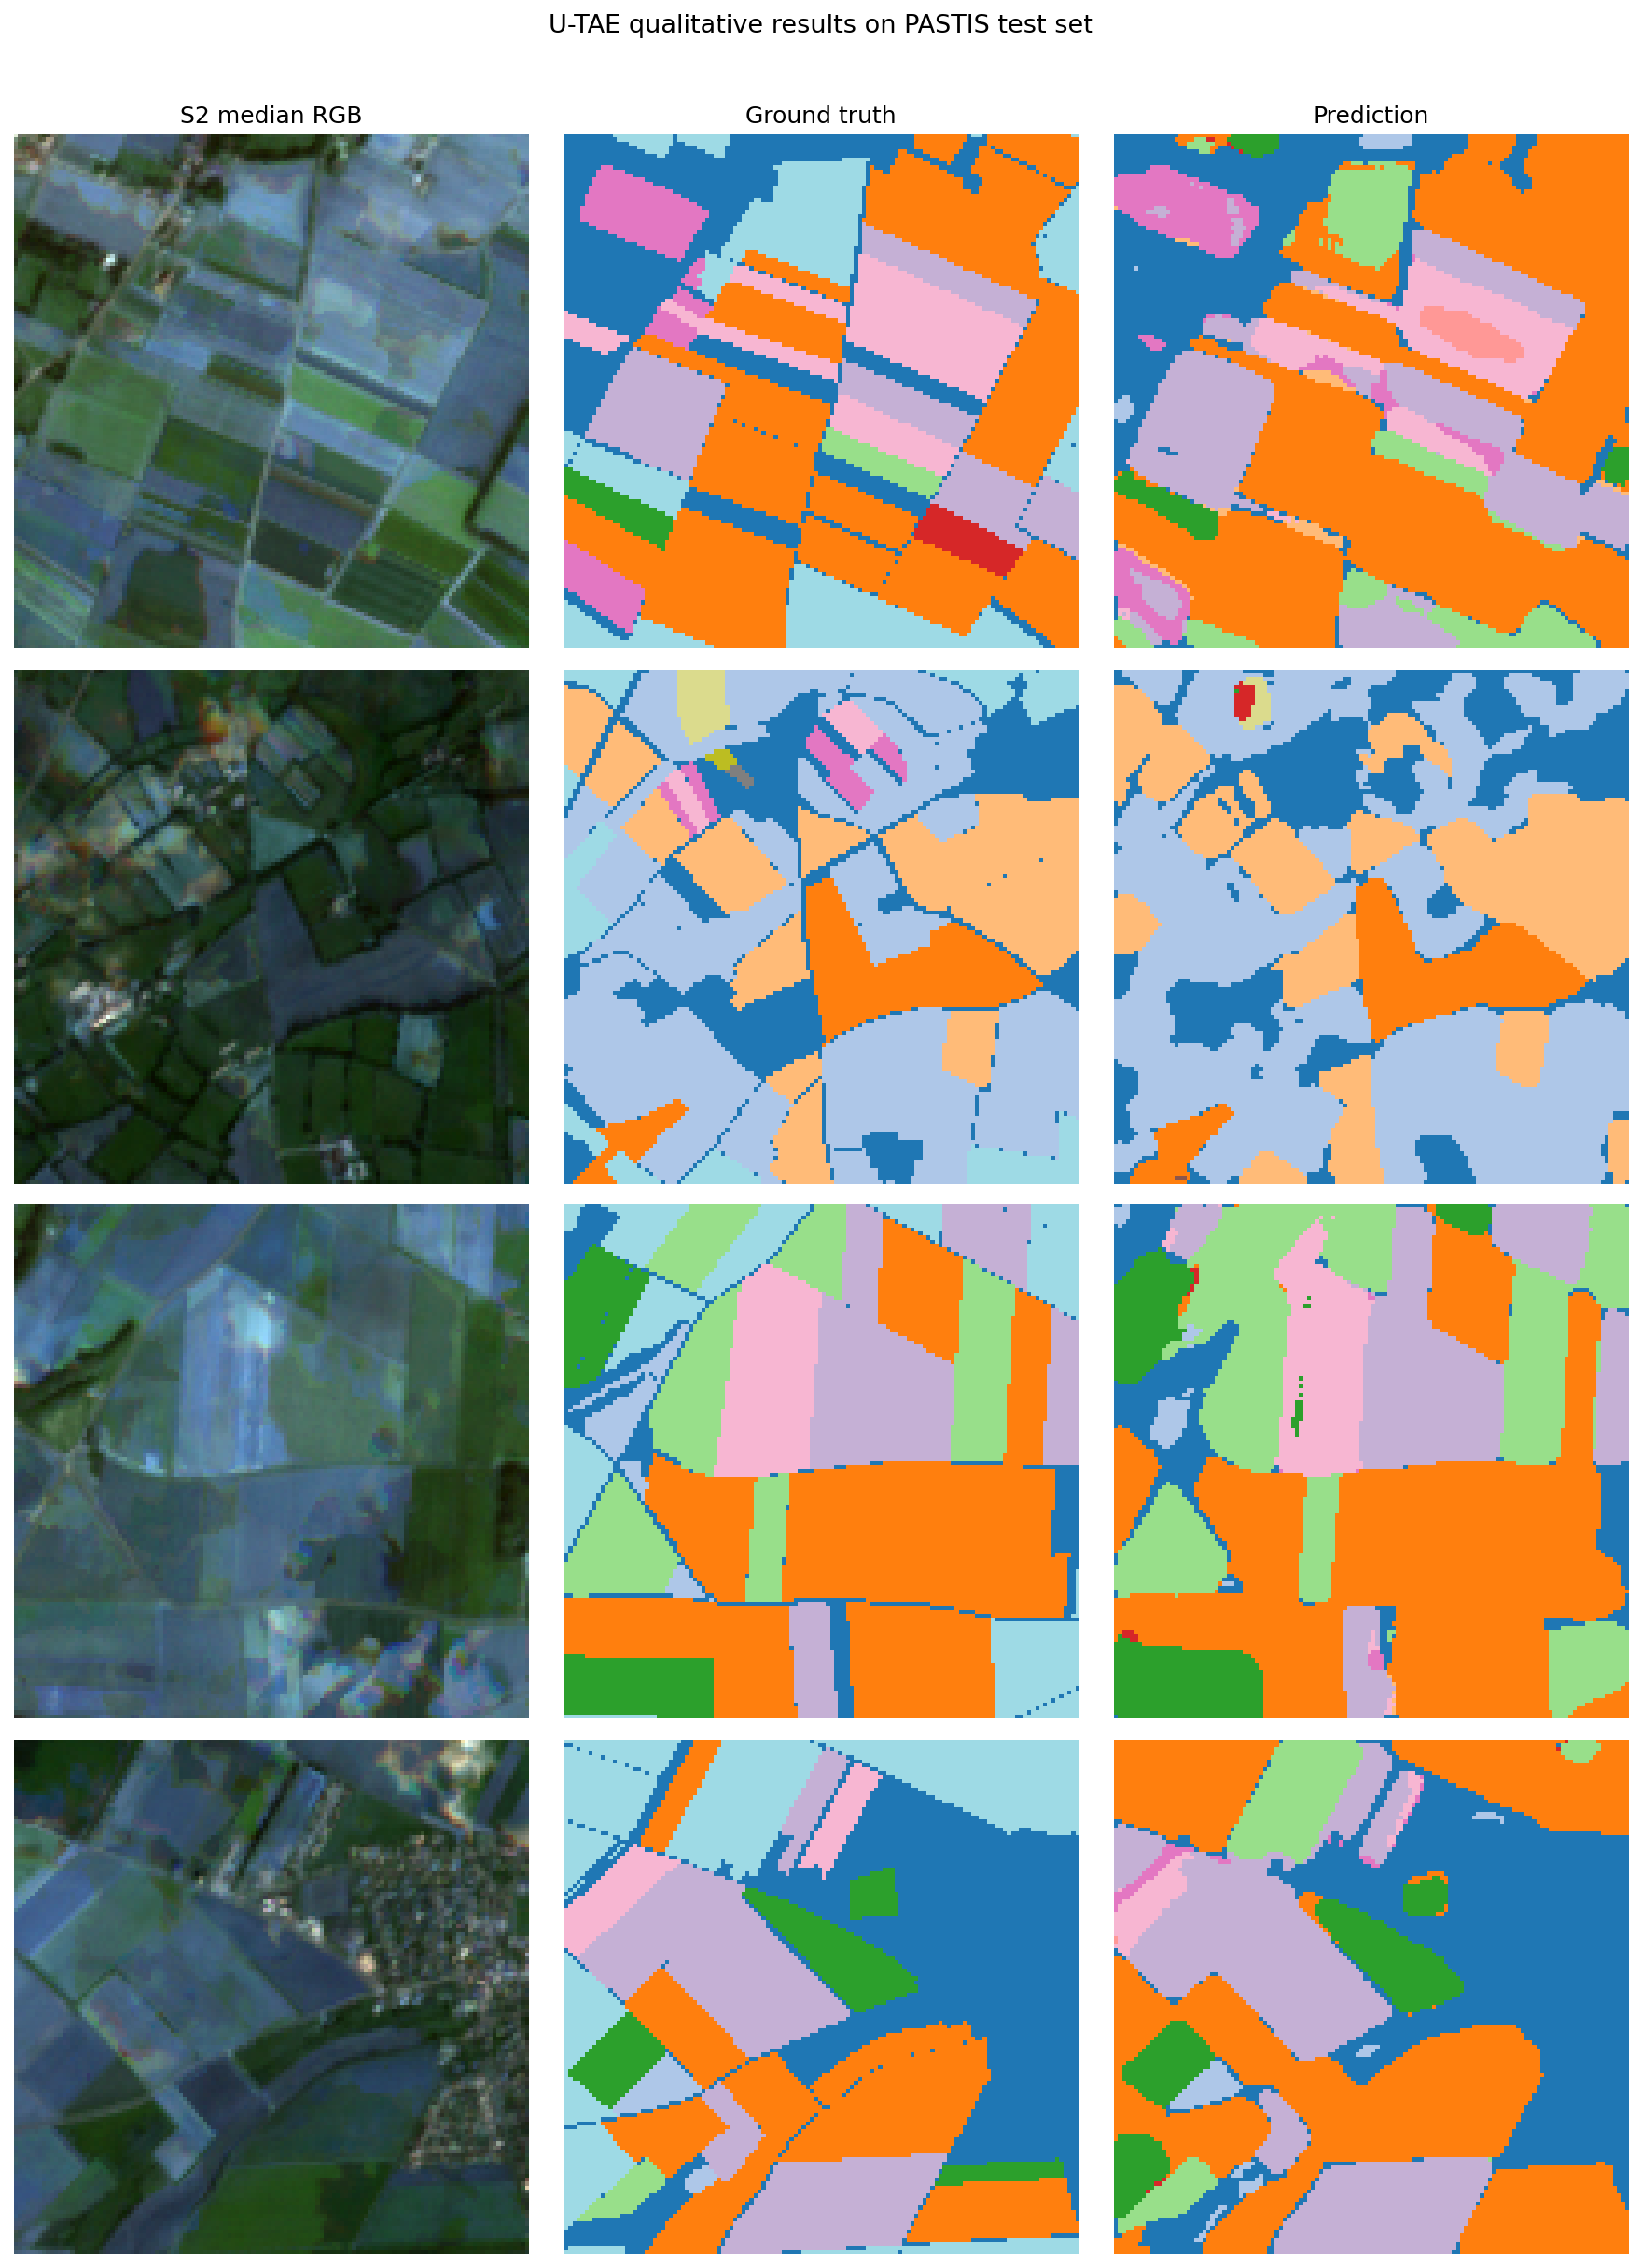

### tsvit

**Matriz de confusion**

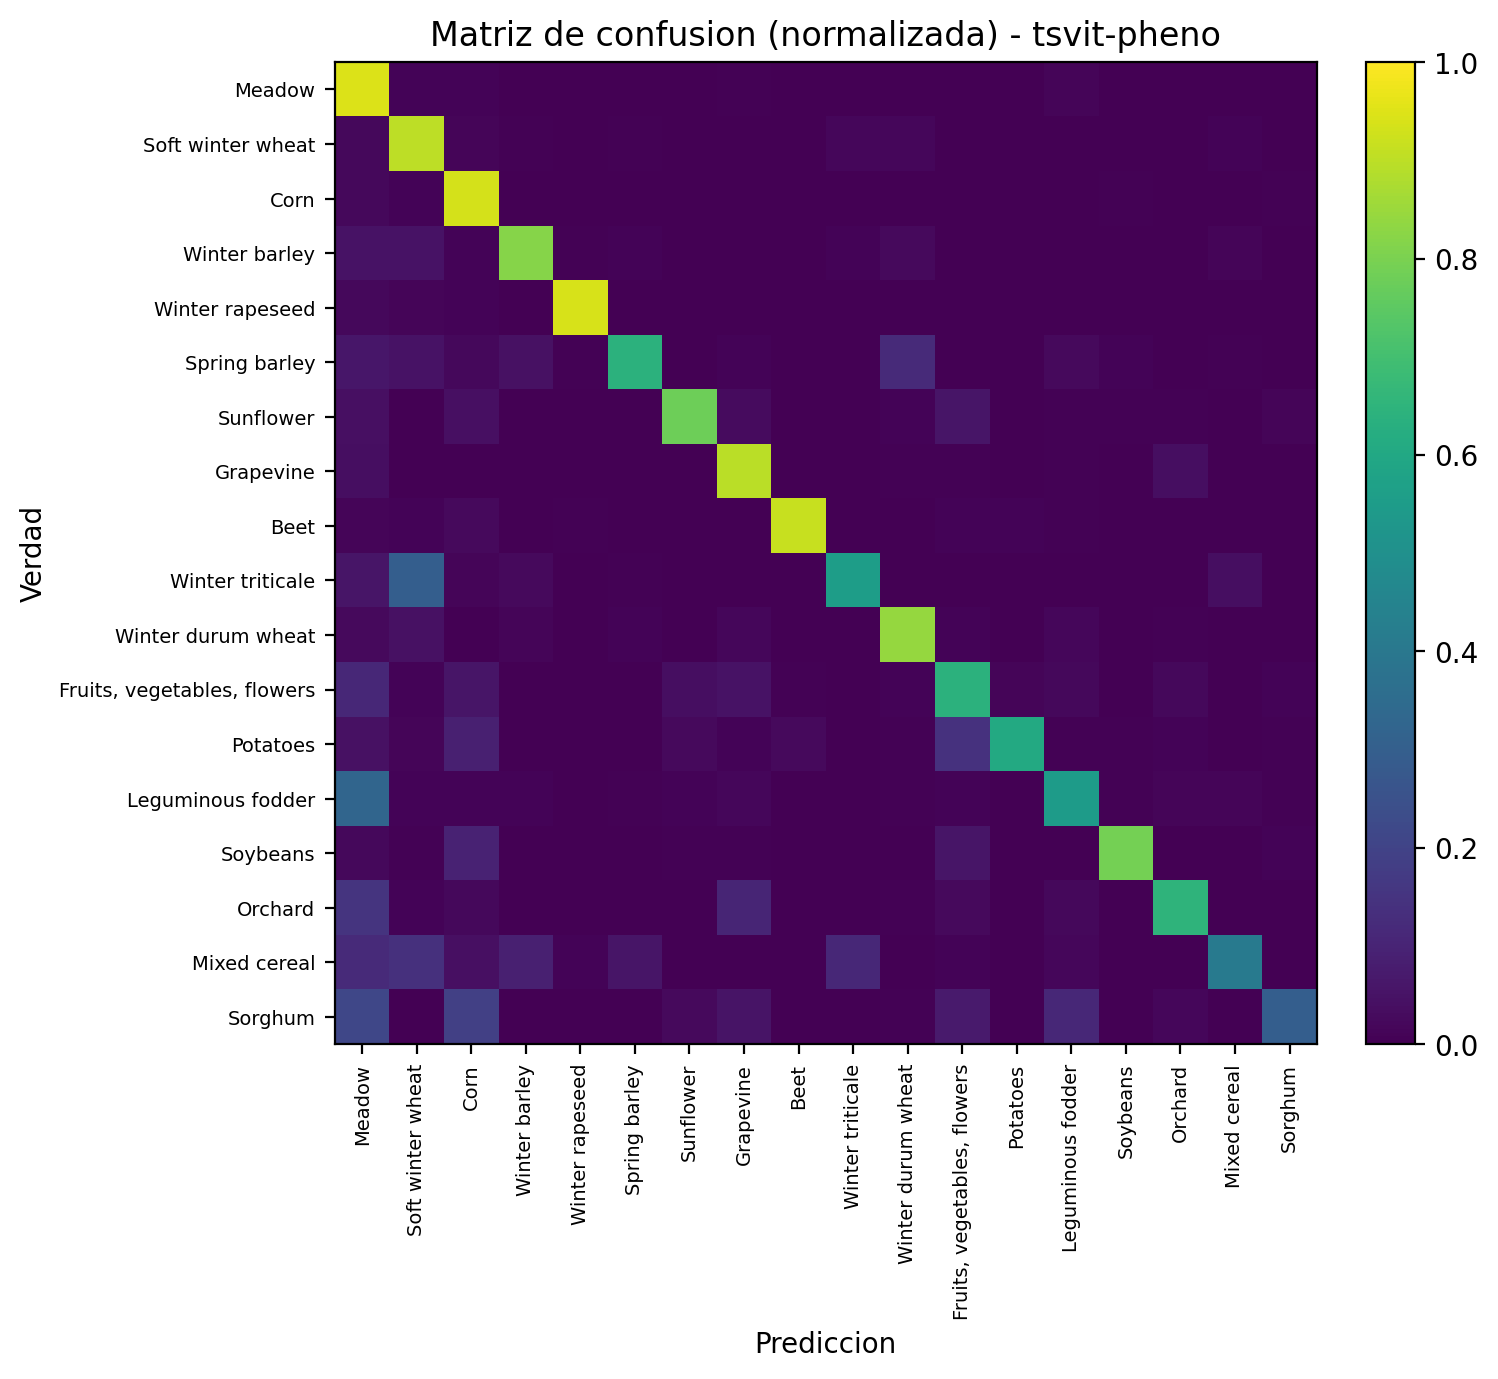

**RGB / verdad / prediccion**

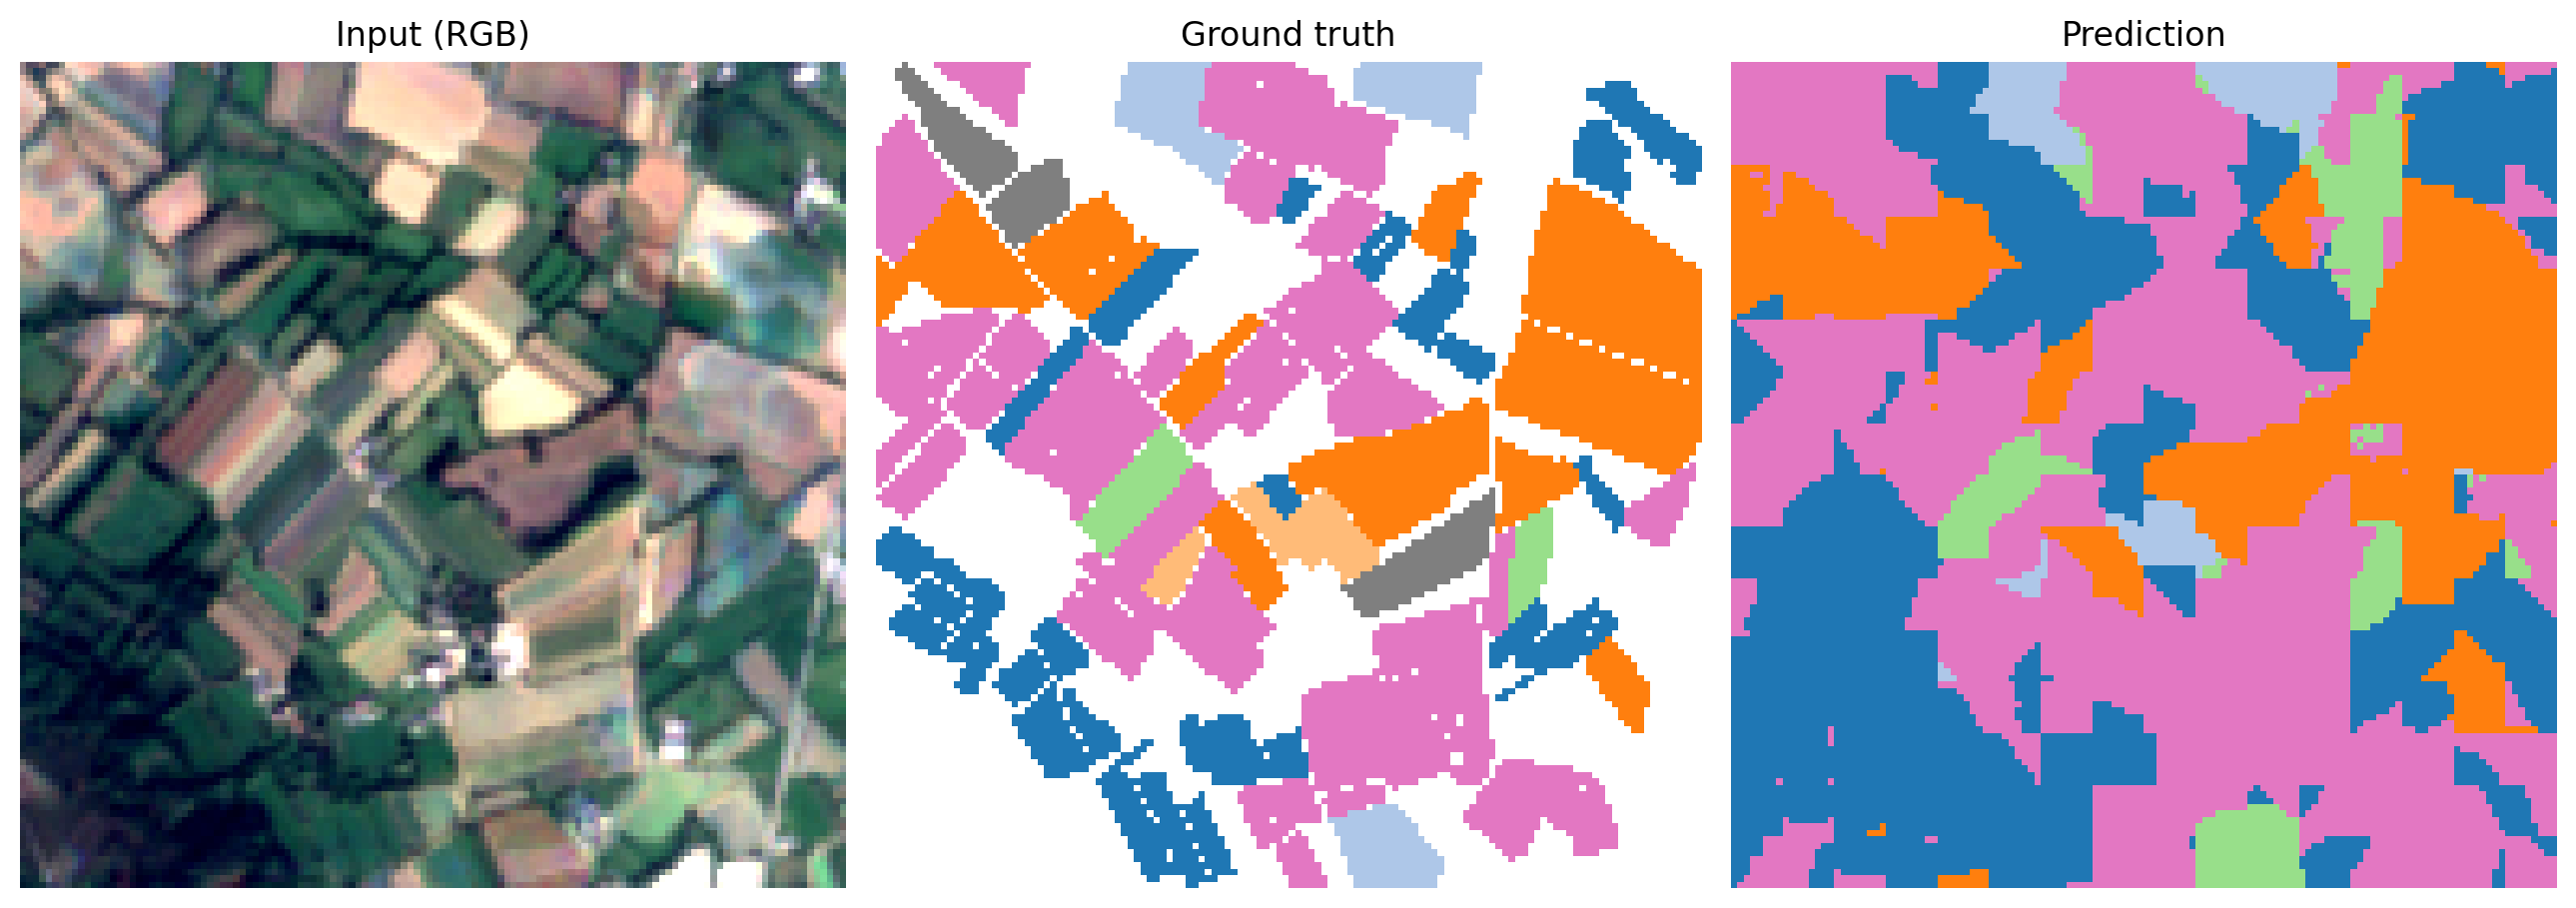

In [5]:
# --- Galeria de figuras por modelo (desde figures/ en Drive) ---
from IPython.display import Image, Markdown, display

def _find_fig(key, model):
    # Acepta el nombre exacto y variantes con sufijo (p.ej. anysat -> anysat_fast).
    _exact = FIGURES / f'{key}_{model}.png'
    if _exact.exists():
        return _exact
    _alt = sorted(FIGURES.glob(f'{key}_{model}_*.png'))
    if _alt:
        return _alt[0]
    # Fallback us-025: figuras de DeepLab/TSViT en paper/figures/us-025/ con sus
    # nombres reales (complementa el Drive compartido, no lo reemplaza).
    _US025_FIG = Path('paper/figures/us-025')
    _US025_MAP = {
        ('confusion', 'deeplabv3plus'): 'deeplab_confusion_semantic18.png',
        ('samples', 'deeplabv3plus'): 'deeplab_semantic18_pred_example_0.png',
        ('confusion', 'tsvit'): 'tsvit_confusion_tsvit-pheno.png',
        ('samples', 'tsvit'): 'tsvit_pred_example_0.png',
    }
    _name = _US025_MAP.get((key, model))
    if _name:
        _p = _US025_FIG / _name
        if _p.exists():
            return _p
    return None

_fig_types = [('curves', 'Curvas de entrenamiento'),
              ('per_class_iou', 'IoU por clase'),
              ('confusion', 'Matriz de confusion'),
              ('samples', 'RGB / verdad / prediccion')]
for _m in EXPECTED:
    display(Markdown(f'### {_m}'))
    _shown = False
    for _key, _label in _fig_types:
        _f = _find_fig(_key, _m)
        if _f is not None:
            display(Markdown(f'**{_label}**'))
            display(Image(filename=str(_f)))
            _shown = True
    if not _shown:
        display(Markdown(f'_Pendiente: aun no hay figuras para `{_m}` (correr su notebook de entrenamiento)._'))

## Arquitectura: DeepLabv3+ (modelo #2, us-025)

**DeepLabv3+** es una CNN encoder-decoder cuyo nucleo es el modulo **ASPP**
(Atrous Spatial Pyramid Pooling): un banco de convoluciones dilatadas a varias
escalas que captura contexto fino y grueso sin perder resolucion espacial. El
encoder es **MobileNetV3-Large**, una columna vertebral ligera que permite
entrenar incluso sin GPU dedicada.

Es un segmentador **2D**: no consume la serie temporal completa, sino una
composicion de la temporada (el dataset colapsa las `T` fechas Sentinel-2 por
**mediana por pixel** antes del forward). Es deliberadamente el punto de
comparacion "sin tiempo" frente a los modelos temporales.

**Resultados (fold 4, 482 parches):** mIoU 0.2709 / F1-macro 0.3864 en las 18
clases; con la agrupacion HCAT de 6 grupos sube a mIoU 0.4682 / F1-macro 0.6009.
La brecha frente a TSViT cuantifica cuanto aporta leer el calendario de
crecimiento. Detalle en `notebooks/segmentation/5a_deeplabv3plus.ipynb`.

## Arquitectura: TSViT + rama fenologica (modelo #5, us-025)

**TSViT** (*Temporo-Spatial Vision Transformer*, Tarasiou et al. 2023) segmenta
consumiendo la **serie temporal completa** de cada parche. Invierte el orden de
un video-ViT: aplica primero un **encoder temporal** sobre las `T` fechas (con
positional encoding indexado por el dia del ano real, robusto a las revisitas
irregulares de Sentinel-2) y despues el **encoder espacial**. Usa **K cls
tokens**, uno por clase de cultivo.

Comparamos dos variantes:

- **`tsvit`** (base): solo el transformer factorizado temporal-espacial.
- **`tsvit-pheno`**: agrega una **rama fenologica-contrastiva** (Wen et al. 2025)
  que alinea por contraste las features visuales de cada pixel con descripciones
  fenologicas por clase generadas por un LLM (InfoNCE pixel<->prototipo).

**Resultados (fold 4, 482 parches):** la base alcanza mIoU 0.6215 / F1-macro
0.7473; la variante con fenologia la supera en las cinco metricas (**mIoU
0.6253** / F1-macro 0.7500), comparable al 65.1 que reporta el paper original.
La mejora se concentra en las clases minoritarias de senal ambigua. Detalle en
`notebooks/segmentation/5b_tsvit.ipynb`.

> **El mejor modelo individual al momento es `tsvit-pheno`** (la variante con la
> rama fenologica). Solo se considera esta variante como candidata: `tsvit` base
> queda como referencia para cuantificar el aporte de la fenologia.

## Seleccion de los 2 mejores modelos

Por la metrica principal (mIoU); empate se rompe por F1-macro -> pixel-accuracy.

In [6]:
# --- Top-2 ---
if table.height >= 2:
    top2 = table.head(2)
    print('Top-2 por mIoU:', top2['model'].to_list())
    top2.select([c for c in _cols if c in top2.columns])
else:
    print('Se requieren >=2 modelos para seleccionar el top-2.')
    top2 = table

Top-2 por mIoU: ['tsvit-pheno', 'tsvit']


## Ajuste fino del top-2 (30 pts)

Cada modelo del top-2 se afina con **Optuna (>=30 trials)** sobre `lr`, `weight_decay` y `batch_size`, reusando `ml.train.train_segmentation.run_training` (ver el hook al final de cada notebook de modelo, p. ej. `04d_segmentation_unet`). Los resultados afinados se exportan a `reports/segmentation/metrics/tuning_<modelo>.parquet` y se cargan aqui.

In [7]:
# --- Resultados del ajuste fino (si existen) ---
# Cada notebook de modelo del top-2 corre Optuna y exporta tuning_<modelo>.parquet a metrics/.
tuning_parts = sorted(REPORTS.glob('tuning_*.parquet'))
if tuning_parts:
    tuning = pl.concat([pl.read_parquet(p) for p in tuning_parts], how='vertical_relaxed')
    display(tuning)
else:
    print('Pendiente: ejecutar la celda de Optuna en los notebooks del top-2 '
          f'({top2["model"].to_list() if table.height else "unet, anysat"}) '
          'para generar tuning_<modelo>.parquet.')
    tuning = pl.DataFrame()

Pendiente: ejecutar la celda de Optuna en los notebooks del top-2 (['tsvit-pheno', 'tsvit']) para generar tuning_<modelo>.parquet.


El ajuste fino se corrio con Optuna, 30 trials por modelo y pruning para cortar los malos. En AnySat, como el encoder esta congelado, se cachearon sus features una sola vez y cada trial entreno solo la cabeza lineal: el mejor trial (lr 0.0065, weight_decay 0.0038) llego a mIoU 0.63 sobre 6 grupos en apenas 8 epocas, por encima del 0.59 del modelo base de 30 epocas. Es decir, con mejor learning rate la cabeza converge mas rapido y un poco mejor.

En la U-Net cada trial reentrena la red completa, asi que para que 30 trials fueran viables se uso un subset de 150 patches y 5 epocas; el mejor trial dio mIoU 0.35, por debajo del 0.45 del modelo base, lo esperable con tan pocas epocas y datos. Aca el tuning sirve para rankear hiperparametros, no para superar al base: se queda con esa configuracion y se reentrenaria a epocas completas para el modelo final.

## Modelo individual final (10 pts)

Eleccion argumentada con trade-offs (no solo la metrica):

- **Rendimiento**: mIoU / F1-macro tras el ajuste fino.
- **Costo de computo**: tiempo de entrenamiento e inferencia (relevante para el presupuesto L4/H100 del proyecto).
- **Interpretabilidad y robustez**: las CNN (U-Net/DeepLabv3+) son mas simples de diagnosticar; los modelos temporales (U-TAE/TSViT) capturan fenologia; AnySat ofrece un FM congelado con minima capacidad entrenable.

> Completar tras la corrida real con el modelo ganador y su justificacion.

In [8]:
# --- Modelo final + sus reportes visuales ---
from IPython.display import Image, Markdown, display
if table.height:
    final_model = table.row(0, named=True)['model']
    _r = table.row(0, named=True)
    display(Markdown(
        f'**Modelo individual final (por mIoU): `{final_model}`** - '
        f'mIoU 6 grupos = {_r.get("miou_grouped")}, '
        f'F1-macro 6 grupos = {_r.get("f1_macro_grouped")}'
    ))
    for _key in ('confusion', 'per_class_iou', 'samples'):
        _f = _find_fig(_key, final_model)
        if _f is not None:
            display(Image(filename=str(_f)))
else:
    print('Definir el modelo final tras consolidar los modelos.')

**Modelo individual final (por mIoU): `tsvit-pheno`** - mIoU 6 grupos = None, F1-macro 6 grupos = None

## Conclusiones y checklist de la rubrica

Entre los resultados, AnySat es el mejor por margen: mIoU 0.59, F1-macro 0.72 y exactitud 0.72 sobre los 6 grupos HCAT, frente a 0.45, 0.59 y 0.72 de la U-Net, y la ventaja crece en las 18 clases planas. Lo notable es que AnySat lo logra entrenando solo unos 30 mil parametros de la cabeza sobre un encoder congelado, mientras la U-Net entrena la red entera. El ajuste fino confirma la tendencia: la cabeza de AnySat, con mejor learning rate, sube a mIoU 0.63 en pocas epocas.

Con la informacion disponible, el modelo individual final provisional es AnySat, por mejor desempeno y menor costo de entrenamiento. La eleccion definitiva queda sujeta a los cuatro modelos que faltan, en particular los temporales (U-TAE, TSViT) que tambien aprovechan la fenologia.